In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import re
from pathlib import Path
from collections import defaultdict

def display_dataset_schema(directory_path: str, current_depth: int = 0, prefix: str = "") -> None:
    """
    Devasa veri setlerinin iskeletini (şemasını) çıkarmak için klasörleri desenlerine,
    dosyaları ise uzantılarına göre gruplayarak ağaç yapısında yazdırır.

    Args:
        directory_path (str): İncelenecek kök dizinin yolu.
        current_depth (int): Rekürsif çağrılarda mevcut derinliği takip eder.
        prefix (str): Görsel ağaç dallarını oluşturmak için kullanılan önek.
    """
    dir_path = Path(directory_path)

    if not dir_path.exists() or not dir_path.is_dir():
        if current_depth == 0:
            print(f"Hata: '{directory_path}' adında bir dizin bulunamadı.")
        return

    if current_depth == 0:
        print(f"📂 {dir_path.name}/")

    try:
        items = list(dir_path.iterdir())
    except PermissionError:
        print(f"{prefix}└── 🚫 Erişim Reddedildi")
        return

    # 1. DOSYALARI GRUPLA (Uzantıya göre)
    files = [p for p in items if p.is_file()]
    file_groups = defaultdict(int)

    for f in files:
        if f.suffix:
            # Örn: .jpg, .csv dosyalarını grupla
            file_groups[f"*{f.suffix.lower()}"] += 1
        else:
            # Uzantısı olmayan dosyaları (README, LICENSE vb.) doğrudan isimleriyle al
            file_groups[f.name] += 1

    # 2. KLASÖRLERİ GRUPLA (İsim desenine göre)
    dirs = [p for p in items if p.is_dir()]
    dir_patterns = defaultdict(list)

    for d in dirs:
        # Klasör ismindeki sayıları 'X' ile değiştir.
        # Örn: "2023-05-12" -> "X-X-X", "batch_01" -> "batch_X", "train" -> "train"
        pattern = re.sub(r'\d+', 'X', d.name)
        dir_patterns[pattern].append(d)

    # 3. YAZDIRILACAK ÖĞELERİ SIRAYA DİZ
    items_to_print = []

    # Klasör gruplarını ekle
    for pattern, dir_list in sorted(dir_patterns.items()):
        if len(dir_list) > 1:
            items_to_print.append(("dir_group", pattern, dir_list))
        else:
            items_to_print.append(("dir_single", dir_list[0].name, dir_list[0]))

    # Dosya gruplarını ekle
    for name_or_ext, count in sorted(file_groups.items()):
        items_to_print.append(("file_group", name_or_ext, count))

    total_items = len(items_to_print)
    if total_items == 0:
        return

    # 4. AĞAÇ YAPISINI EKRANA BAS
    for i, item in enumerate(items_to_print):
        is_last_item = (i == total_items - 1)
        pointer = '└── ' if is_last_item else '├── '
        extension_str = '    ' if is_last_item else '│   '

        item_type, key, data = item

        if item_type == "dir_single":
            # Benzersiz klasör (Örn: train, val, src)
            print(f"{prefix}{pointer}📁 {key}/")
            display_dataset_schema(str(data), current_depth + 1, prefix + extension_str)

        elif item_type == "dir_group":
            # Tekrar eden klasör grubu (Örn: Tarih formatlı klasörler)
            print(f"{prefix}{pointer}📁 [{key}] formatında {len(data)} adet klasör/")

            # Şemayı göstermek için gruptan sadece İLK klasörün içine gir
            rep_dir = data[0]
            print(f"{prefix}{extension_str}│   (Örnek yapı '{rep_dir.name}/' altından inceleniyor)")
            display_dataset_schema(str(rep_dir), current_depth + 1, prefix + extension_str)

        elif item_type == "file_group":
            # Gruplanmış dosyalar
            if data > 1:
                print(f"{prefix}{pointer}📄 {key} ({data} adet)")
            else:
                print(f"{prefix}{pointer}📄 {key}")

# Kullanım:
TARGET_DIR = "/content/drive/MyDrive/archive"
display_dataset_schema(TARGET_DIR)

📂 archive/
├── 📁 Data_Annotated_Subset_Object_Detectors/
│   ├── 📁 testing/
│   │   ├── 📁 Apr Month/
│   │   │   ├── 📄 *.jpg (99 adet)
│   │   │   └── 📄 *.txt (100 adet)
│   │   ├── 📁 Aug Month/
│   │   │   ├── 📄 *.jpg (100 adet)
│   │   │   └── 📄 *.txt (100 adet)
│   │   └── 📁 Jan Month/
│   │       ├── 📄 *.jpg (100 adet)
│   │       └── 📄 *.txt (100 adet)
│   ├── 📁 testing_metadata/
│   │   └── 📄 *.csv (3 adet)
│   ├── 📁 training/
│   │   ├── 📁 Feb Day/
│   │   │   ├── 📄 *.jpg (100 adet)
│   │   │   └── 📄 *.txt (100 adet)
│   │   ├── 📁 Feb Month/
│   │   │   ├── 📄 *.jpg (200 adet)
│   │   │   └── 📄 *.txt (200 adet)
│   │   ├── 📁 Feb Week/
│   │   │   ├── 📄 *.jpg (100 adet)
│   │   │   └── 📄 *.txt (100 adet)
│   │   └── 📁 Mar Week/
│   │       ├── 📄 *.jpg (100 adet)
│   │       └── 📄 *.txt (100 adet)
│   ├── 📁 training_metadata/
│   │   └── 📄 *.csv (3 adet)
│   └── 📁 validation/
│       ├── 📄 *.jpg (51 adet)
│       └── 📄 *.txt (51 adet)
├── 📁 Data_Subset_Autoencoders_Anomaly_Detector

In [ ]:
"""
CR-AE PURE BACKGROUND PIPELINE — v4 (A100 GPU BATCH OPTİMİZE)
================================================================
Google Colab — A100 80GB GPU, 167GB System RAM

AMAÇ:
  LTD Dataset'ten 1500+ temiz pure background klip çıkar.
  Mevcut pure_background klasörü silinip sıfırdan oluşturulur.

HIZLANDIRMA STRATEJİSİ (v3'ten fark):
  v3: pencere pencere YOLO çağrısı → 875 çağrı/gün → ~4.5 saat
  v4: videonun TÜM frame'lerini tek seferde YOLO'ya gönder
      → gün başına ~21 batch çağrısı (512 frame/batch)
      → sonra pencere bazında sonuç kontrol et
      → tahmini toplam: ~40-60 dakika

  Neden hızlı:
    - GPU boşta beklemiyor, sürekli dolu batch işliyor
    - CPU↔GPU transfer sayısı ~40x azalıyor
    - A100 80GB ile 512 frame'lik batch rahat sığar

FİLTRE SIRASI (optimize):
  1. Tüm frame'lere toplu YOLO → frame bazında insan var/yok haritası
  2. Pencere bazında kontrol: 16 frame'in hepsinde insan yoksa → YOLO temiz
  3. YOLO temiz pencerelere hareket tespiti (CPU, çok hızlı)
  4. Her iki filtreyi geçen pencereler → kabul

TEZ TASARIM KARARLARI:
  - Eğitim: Sadece kış (Ocak + Şubat + Mart 2021)
  - 16 frame/klip, 8-frame adımlı sliding window, %50 örtüşme
  - Sıfır insan toleransı (çift katmanlı filtre)

HEDEF: 1500+ klip
"""

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 0 — KURULUM
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess
subprocess.run(['pip', 'install', 'ultralytics', '-q'])

from google.colab import drive
drive.mount('/content/drive')

import cv2, os, shutil, time, json, gc
import numpy as np
from pathlib import Path
from ultralytics import YOLO

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 1 — KONFİGÜRASYON
# ═══════════════════════════════════════════════════════════════════════════════

# --- Yollar ---
LTD_CLIPS      = Path('/content/drive/MyDrive/archive/LTD Dataset/LTD Dataset/Video Clips')
PURE_BG_DIR    = Path('/content/drive/MyDrive/archive/Data_Subset_Autoencoders_Anomaly_Detectors/training/pure_background')
LOCAL_BUFFER   = Path('/content/pure_bg_buffer')
LOG_FILE       = Path('/content/drive/MyDrive/archive/pure_bg_extraction_log_v4.json')

# --- Hedef aylar (kış — tez tasarım kararı) ---
TARGET_MONTHS  = ['202101', '202102', '202103']

# --- Klip parametreleri ---
FRAMES_PER_CLIP   = 16
WINDOW_STEP       = 8       # %50 örtüşme
MIN_CLIPS_PER_DAY = 2
MAX_CLIPS_PER_DAY = 30

# --- YOLO parametreleri ---
YOLO_MODEL     = 'yolov8x.pt'
YOLO_CONF      = 0.15
YOLO_BATCH     = 512         # A100 80GB → 512 frame tek batch'te

# --- Hareket tespiti parametreleri ---
MOTION_PIXEL_THRESH     = 25
MOTION_BLUR_KERNEL      = 5
MOTION_MIN_CONTOUR      = 500
MOTION_MAX_ACTIVE_PAIRS = 2

# --- Diğer ---
JPEG_QUALITY       = 95
FLUSH_EVERY_N_DAYS = 5

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 2 — MEVCUT PURE_BACKGROUND'U TEMİZLE
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("AŞAMA A — Mevcut pure_background siliniyor...")
print("=" * 65)

if PURE_BG_DIR.exists():
    existing_items = list(PURE_BG_DIR.iterdir())
    existing_count = sum(1 for d in existing_items if d.is_dir())
    print(f"Mevcut: {len(existing_items)} öğe ({existing_count} gün klasörü)")
    shutil.rmtree(str(PURE_BG_DIR))
    print("Tamamen silindi ✓")
else:
    print("Zaten yok.")

PURE_BG_DIR.mkdir(parents=True, exist_ok=True)

if LOCAL_BUFFER.exists():
    shutil.rmtree(str(LOCAL_BUFFER))
LOCAL_BUFFER.mkdir(parents=True, exist_ok=True)
print()

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 3 — YOLO MODELİ
# ═══════════════════════════════════════════════════════════════════════════════

print("YOLOv8x yükleniyor (A100 FP16)...")
model = YOLO(YOLO_MODEL)
model.to('cuda')
print("Model hazır.\n")

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 4 — TOPLU YOLO INFERENCE
# ═══════════════════════════════════════════════════════════════════════════════

def batch_yolo_person_map(all_frames: list) -> list:
    """
    Bir videonun TÜM frame'lerini toplu olarak YOLO'ya gönderir.
    Her frame için True (insan var) / False (insan yok) listesi döner.

    A100 80GB GPU ile 512 frame'lik batch'ler halinde işler.
    Tipik bir video ~200-300 frame → tek batch'te biter.

    Args:
        all_frames: list of BGR numpy arrays

    Returns:
        person_map: list of bool, len == len(all_frames)
    """
    n = len(all_frames)
    person_map = [False] * n

    # Batch'lere böl
    for batch_start in range(0, n, YOLO_BATCH):
        batch_end = min(batch_start + YOLO_BATCH, n)
        batch_frames = all_frames[batch_start:batch_end]

        results = model(
            batch_frames,
            classes=[0],       # sadece insan
            conf=YOLO_CONF,    # 0.15
            verbose=False,
            half=True,         # FP16
            device='cuda',
        )

        for i, r in enumerate(results):
            if len(r.boxes) > 0:
                person_map[batch_start + i] = True

    return person_map


# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 5 — HAREKET TESPİTİ
# ═══════════════════════════════════════════════════════════════════════════════

def has_significant_motion(frames_bgr: list) -> bool:
    """
    Ardışık frame çiftleri arasında hareket analizi.

    - Rüzgarda sallanan ağaç: küçük dağınık contour (<500px) → GEÇ
    - Yürüyen insan: büyük kompakt contour (>500px) → RED
    - 2+ aktif çiftte büyük hareket → RED
    """
    grays = []
    for f in frames_bgr:
        g = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)
        g = cv2.GaussianBlur(g, (MOTION_BLUR_KERNEL, MOTION_BLUR_KERNEL), 0)
        grays.append(g)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    active_pairs = 0

    for i in range(len(grays) - 1):
        diff = cv2.absdiff(grays[i], grays[i + 1])
        _, thresh = cv2.threshold(diff, MOTION_PIXEL_THRESH, 255, cv2.THRESH_BINARY)
        dilated = cv2.dilate(thresh, kernel, iterations=2)
        contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if any(cv2.contourArea(c) >= MOTION_MIN_CONTOUR for c in contours):
            active_pairs += 1
            if active_pairs >= MOTION_MAX_ACTIVE_PAIRS:
                return True

    return False


# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 6 — VİDEO İŞLEME (TOPLU YOLO + PENCERE BAZLI FİLTRE)
# ═══════════════════════════════════════════════════════════════════════════════

def process_video(video_path: Path, video_idx: int):
    """
    Tek bir videoyu işler:
      1. Tüm frame'leri oku
      2. Toplu YOLO → frame bazında person_map
      3. Pencere bazında person_map kontrol (16 frame'in hepsinde False ise → YOLO temiz)
      4. YOLO temiz pencerelere hareket tespiti
      5. Her iki filreyi geçenler → kabul

    Returns:
        (clean_clips, stats)
        clean_clips: [(clip_name, frames), ...]
        stats: dict
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return [], {'windows': 0, 'yolo_reject': 0, 'motion_reject': 0, 'clean': 0}

    all_frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        all_frames.append(frame)
    cap.release()

    total = len(all_frames)
    if total < FRAMES_PER_CLIP:
        return [], {'windows': 0, 'yolo_reject': 0, 'motion_reject': 0, 'clean': 0}

    # ── ADIM 1: Toplu YOLO — tüm frame'ler tek seferde ──
    person_map = batch_yolo_person_map(all_frames)

    # ── ADIM 2: Pencere bazında kontrol ──
    clean_clips = []
    n_windows = 0
    n_yolo_reject = 0
    n_motion_reject = 0

    for start in range(0, total - FRAMES_PER_CLIP + 1, WINDOW_STEP):
        n_windows += 1
        end = start + FRAMES_PER_CLIP

        # YOLO kontrolü: bu penceredeki 16 frame'den herhangi birinde insan var mı?
        if any(person_map[start:end]):
            n_yolo_reject += 1
            continue

        # Hareket kontrolü: YOLO temiz ama büyük hareket var mı?
        window_frames = all_frames[start:end]
        if has_significant_motion(window_frames):
            n_motion_reject += 1
            continue

        # Her iki filtreyi geçti → kabul
        clip_name = f"clip_{video_idx}_{start:04d}"
        clean_clips.append((clip_name, window_frames))

    stats = {
        'windows': n_windows,
        'yolo_reject': n_yolo_reject,
        'motion_reject': n_motion_reject,
        'clean': len(clean_clips),
    }

    return clean_clips, stats


def process_day(day_dir: Path):
    """
    Bir günün tüm videolarını işler.
    """
    day_name = day_dir.name
    mp4_files = sorted(day_dir.glob('*.mp4'))

    if not mp4_files:
        return day_name, [], {
            'videos': 0, 'windows': 0,
            'yolo_reject': 0, 'motion_reject': 0, 'clean': 0
        }

    all_clean = []
    day_stats = {'videos': len(mp4_files), 'windows': 0, 'yolo_reject': 0, 'motion_reject': 0, 'clean': 0}

    for vid_idx, mp4 in enumerate(mp4_files):
        clips, v_stats = process_video(mp4, vid_idx)
        all_clean.extend(clips)

        day_stats['windows'] += v_stats['windows']
        day_stats['yolo_reject'] += v_stats['yolo_reject']
        day_stats['motion_reject'] += v_stats['motion_reject']
        day_stats['clean'] += v_stats['clean']

    # Video frame'lerini bellekten temizle
    gc.collect()

    return day_name, all_clean, day_stats


# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 7 — KAYIT FONKSİYONLARI
# ═══════════════════════════════════════════════════════════════════════════════

def save_clips_to_local(day_name: str, clips: list):
    """
    Yapı: LOCAL_BUFFER/YYYYMMDD/clip_X_YYYY/frame_001.jpg ... frame_016.jpg
    """
    day_dir = LOCAL_BUFFER / day_name
    day_dir.mkdir(parents=True, exist_ok=True)

    for clip_name, frames in clips:
        clip_dir = day_dir / clip_name
        clip_dir.mkdir(parents=True, exist_ok=True)
        for i, frame in enumerate(frames, start=1):
            cv2.imwrite(
                str(clip_dir / f'frame_{i:03d}.jpg'),
                frame,
                [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY]
            )


def flush_local_to_drive():
    """Local buffer → Drive toplu taşıma."""
    copied_days = 0
    copied_clips = 0

    for day_dir in sorted(LOCAL_BUFFER.iterdir()):
        if not day_dir.is_dir():
            continue

        dest_day = PURE_BG_DIR / day_dir.name
        dest_day.mkdir(parents=True, exist_ok=True)

        for clip_dir in sorted(day_dir.iterdir()):
            if not clip_dir.is_dir():
                continue
            dest_clip = dest_day / clip_dir.name
            if dest_clip.exists():
                shutil.rmtree(str(dest_clip))
            shutil.copytree(str(clip_dir), str(dest_clip))
            copied_clips += 1

        shutil.rmtree(str(day_dir))
        copied_days += 1

    return copied_days, copied_clips


# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 8 — ANA DÖNGÜ
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("AŞAMA B — LTD → Pure Background (Toplu GPU Inference)")
print("  Filtre: Toplu YOLO (GPU batch) → Hareket Tespiti (CPU)")
print("=" * 65)

target_days = sorted([
    d for d in LTD_CLIPS.iterdir()
    if d.is_dir() and any(d.name.startswith(m) for m in TARGET_MONTHS)
])

print(f"Hedef gün: {len(target_days)} (Ocak+Şubat+Mart 2021)")
print(f"YOLO: {YOLO_MODEL} | Conf: {YOLO_CONF} | Batch: {YOLO_BATCH} frame")
print(f"Hareket: contour≥{MOTION_MIN_CONTOUR}px | aktif çift≥{MOTION_MAX_ACTIVE_PAIRS} → RED")
print(f"Klip: {FRAMES_PER_CLIP} frame | adım: {WINDOW_STEP} | gün başına: {MIN_CLIPS_PER_DAY}–{MAX_CLIPS_PER_DAY}")
print()

global_stats = {
    'start_time': time.strftime('%Y-%m-%d %H:%M:%S'),
    'config': {
        'target_months': TARGET_MONTHS,
        'frames_per_clip': FRAMES_PER_CLIP,
        'window_step': WINDOW_STEP,
        'yolo_model': YOLO_MODEL,
        'yolo_conf': YOLO_CONF,
        'yolo_batch': YOLO_BATCH,
        'motion_min_contour': MOTION_MIN_CONTOUR,
        'motion_max_active_pairs': MOTION_MAX_ACTIVE_PAIRS,
        'min_clips_per_day': MIN_CLIPS_PER_DAY,
        'max_clips_per_day': MAX_CLIPS_PER_DAY,
    },
    'days_processed': 0,
    'days_skipped': 0,
    'total_clips': 0,
    'total_frames': 0,
    'total_windows': 0,
    'total_yolo_reject': 0,
    'total_motion_reject': 0,
    'per_day': {},
}

t_start = time.time()
flush_counter = 0

for day_idx, day_dir in enumerate(target_days):

    t_day = time.time()
    print(f"\n[{day_idx+1}/{len(target_days)}] {day_dir.name}", end=" ", flush=True)

    day_name, all_clean, day_stats = process_day(day_dir)

    global_stats['total_windows'] += day_stats['windows']
    global_stats['total_yolo_reject'] += day_stats['yolo_reject']
    global_stats['total_motion_reject'] += day_stats['motion_reject']

    day_time = time.time() - t_day

    # Minimum klip kontrolü
    if len(all_clean) < MIN_CLIPS_PER_DAY:
        print(f"→ ATLA ({len(all_clean)} klip) | "
              f"Y:{day_stats['yolo_reject']} M:{day_stats['motion_reject']} | "
              f"{day_time:.0f}s", flush=True)
        global_stats['days_skipped'] += 1
        global_stats['per_day'][day_name] = {**day_stats, 'status': 'skipped', 'accepted': 0}
        continue

    # Maksimum sınır — eşit aralıklı seçim
    if len(all_clean) > MAX_CLIPS_PER_DAY:
        step = len(all_clean) / MAX_CLIPS_PER_DAY
        indices = [int(i * step) for i in range(MAX_CLIPS_PER_DAY)]
        selected = [all_clean[i] for i in indices]
    else:
        selected = all_clean

    save_clips_to_local(day_name, selected)

    global_stats['days_processed'] += 1
    global_stats['total_clips'] += len(selected)
    global_stats['total_frames'] += len(selected) * FRAMES_PER_CLIP
    global_stats['per_day'][day_name] = {**day_stats, 'status': 'ok', 'accepted': len(selected)}

    elapsed = time.time() - t_start
    remaining_days = len(target_days) - (day_idx + 1)
    avg_per_day = elapsed / (day_idx + 1)
    eta = remaining_days * avg_per_day

    print(f"→ {len(selected)}/{len(all_clean)} klip | "
          f"Y:{day_stats['yolo_reject']} M:{day_stats['motion_reject']} | "
          f"Toplam:{global_stats['total_clips']} | "
          f"{day_time:.0f}s | ETA:{eta/60:.0f}dk", flush=True)

    # Periyodik flush
    flush_counter += 1
    if flush_counter % FLUSH_EVERY_N_DAYS == 0:
        fd, fc = flush_local_to_drive()
        print(f"  FLUSH: {fc} klip → Drive", flush=True)

    # Bellek temizliği
    del all_clean, selected
    gc.collect()

# Son flush
fd, fc = flush_local_to_drive()
if fc > 0:
    print(f"\nSon flush: {fc} klip → Drive")

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 9 — RAPOR
# ═══════════════════════════════════════════════════════════════════════════════

total_time = time.time() - t_start
global_stats['end_time'] = time.strftime('%Y-%m-%d %H:%M:%S')
global_stats['total_time_minutes'] = round(total_time / 60, 1)

with open(str(LOG_FILE), 'w', encoding='utf-8') as f:
    json.dump(global_stats, f, indent=2, ensure_ascii=False)

print("\n" + "=" * 65)
print("  PURE BACKGROUND v4 — RAPOR")
print("  (Toplu GPU Batch + Hareket Filtresi)")
print("=" * 65)
print(f"  Süre               : {total_time/60:.1f} dakika")
print(f"  İşlenen gün        : {global_stats['days_processed']}")
print(f"  Atlanan gün        : {global_stats['days_skipped']}")
print(f"  Toplam klip        : {global_stats['total_clips']}")
print(f"  Toplam frame       : {global_stats['total_frames']}")
print(f"  Taranan pencere    : {global_stats['total_windows']}")
print(f"  YOLO red           : {global_stats['total_yolo_reject']}")
print(f"  Hareket red        : {global_stats['total_motion_reject']}")

if global_stats['total_windows'] > 0:
    cr = global_stats['total_clips'] / global_stats['total_windows'] * 100
    print(f"  Kabul oranı        : %{cr:.1f}")

print(f"  Çıktı              : {PURE_BG_DIR}")
print()

if global_stats['total_clips'] >= 1500:
    print("  ✅ HEDEF: 1500+ klip başarılı!")
elif global_stats['total_clips'] >= 1000:
    print("  ⚠️  1000+ klip — yeterli olabilir, 1500+ ideal")
else:
    print("  ❌ Hedef altında — parametreleri gevşetmeyi dene")

print()
print("Gün bazlı dağılım (ilk 30):")
print("-" * 50)
for i, (d, info) in enumerate(sorted(global_stats['per_day'].items())[:30]):
    a = info['accepted']
    if info['status'] == 'ok':
        print(f"  {d}: {'█' * min(a, 50)} ({a})")
    else:
        print(f"  {d}: — atlandı")
if len(global_stats['per_day']) > 30:
    print(f"  ... +{len(global_stats['per_day']) - 30} gün")

print("=" * 65)
print("\nRaporu Claude'a yapıştır → testing_final analizine geçelim.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AŞAMA A — Mevcut pure_background siliniyor...
Mevcut: 0 öğe (0 gün klasörü)
Tamamen silindi ✓

YOLOv8x yükleniyor (A100 FP16)...
Model hazır.

AŞAMA B — LTD → Pure Background (Toplu GPU Inference)
  Filtre: Toplu YOLO (GPU batch) → Hareket Tespiti (CPU)
Hedef gün: 83 (Ocak+Şubat+Mart 2021)
YOLO: yolov8x.pt | Conf: 0.15 | Batch: 512 frame
Hareket: contour≥500px | aktif çift≥2 → RED
Klip: 16 frame | adım: 8 | gün başına: 2–30


[1/83] 20210108 → 30/875 klip | Y:1367 M:2 | Toplam:30 | 94s | ETA:128dk

[2/83] 20210109 → 30/4040 klip | Y:3048 M:18 | Toplam:60 | 281s | ETA:253dk

[3/83] 20210110 → 30/1816 klip | Y:802 M:0 | Toplam:90 | 106s | ETA:214dk

[4/83] 20210111 → 30/5136 klip | Y:3409 M:57 | Toplam:120 | 351s | ETA:274dk

[5/83] 20210112 → 30/293 klip | Y:81 M:0 | Toplam:150 | 15s | ETA:221dk
  FLUSH: 150 klip → Drive

[6/83] 20210113 → 30/1599 klip | Y:100

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ESKİ DOĞRULAMA ÇIKTILARI TEMİZLENİYOR...
  Silindi: pure_bg_verification_v3

ADIM 0 — Drive → Local SSD
Kopyalanıyor...
Kopyalandı: 74 gün, 2188 klip | 82s

YOLOv8x yükleniyor...
Hazır.

ADIM 1 — YOLO Tarama + Çoklu Frame Tutarlılık
  YOLO conf=0.15 | Min frames=2
  Yüksek güven eşiği=0.3
Toplam: 2188 klip

[20210108] 30 klip | Şüpheli: 0 | Yoksayılan: 0 | ETA:0.8dk
[20210109] 30 klip | Şüpheli: 0 | Yoksayılan: 0 | ETA:0.9dk
[20210110] 30 klip | Şüpheli: 0 | Yoksayılan: 0 | ETA:0.9dk
[20210111] 29 klip | Şüpheli: 0 | Yoksayılan: 1 | ETA:0.9dk
[20210112] 30 klip | Şüpheli: 0 | Yoksayılan: 1 | ETA:0.9dk
[20210113] 30 klip | Şüpheli: 0 | Yoksayılan: 1 | ETA:0.8dk
[20210115] 29 klip | Şüpheli: 1 | Yoksayılan: 1 | ETA:0.8dk
[20210116] 30 klip | Şüpheli: 1 | Yoksayılan: 3 | ETA:0.8dk
[20210117] 30 klip | Şüpheli: 1 | Yoksayılan: 3 | ETA:0.8dk
[20210118] 30 klip | Ş

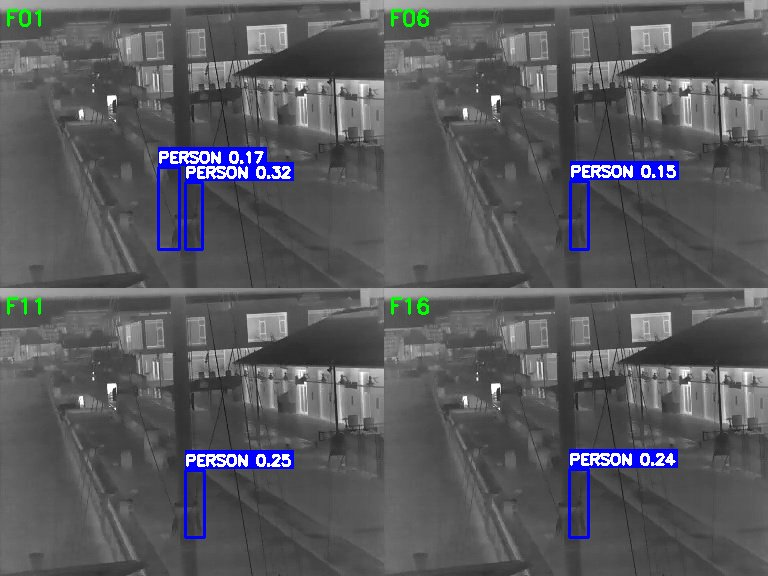


──────────────────────────────────────────────────
  #2 | 20210124/clip_16_1848 | multi_frame_4 | max_conf=0.23
──────────────────────────────────────────────────


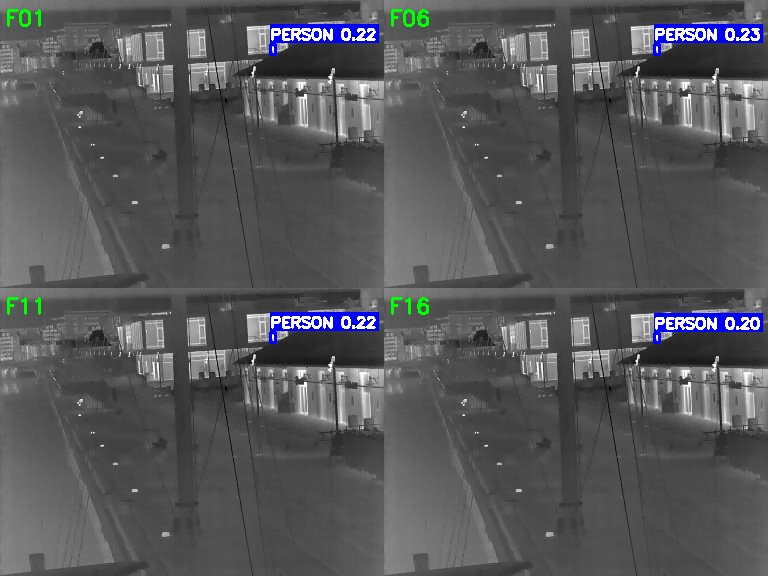


──────────────────────────────────────────────────
  #3 | 20210218/clip_0_2632 | multi_frame_4 | max_conf=0.20
──────────────────────────────────────────────────


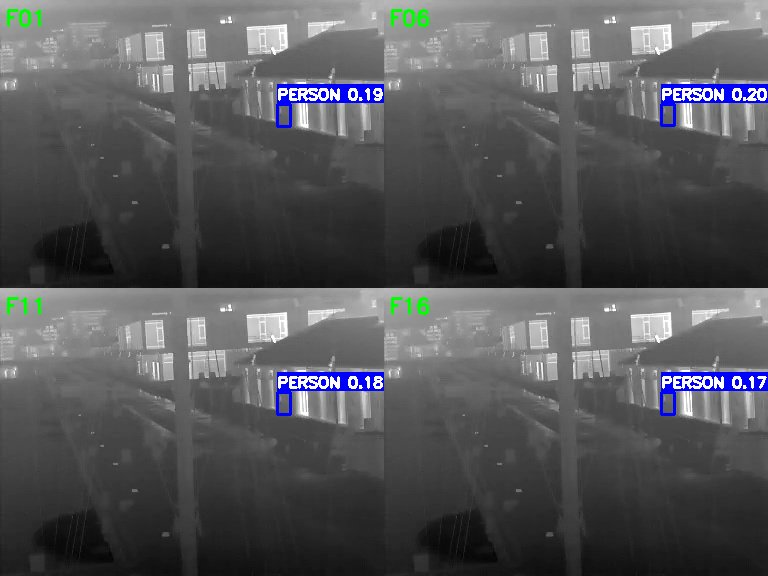


──────────────────────────────────────────────────
  #4 | 20210223/clip_4_2816 | multi_frame_4 | max_conf=0.19
──────────────────────────────────────────────────


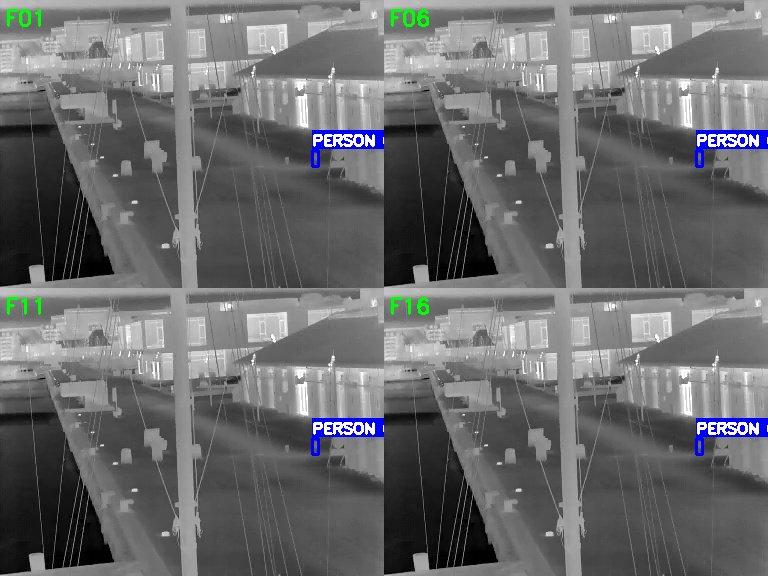


──────────────────────────────────────────────────
  #5 | 20210120/clip_7_0272 | multi_frame_3 | max_conf=0.22
──────────────────────────────────────────────────


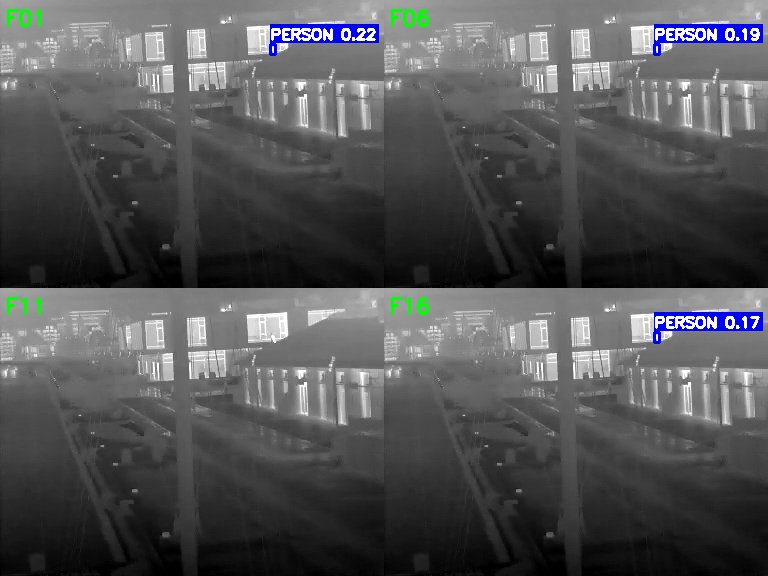


──────────────────────────────────────────────────
  #6 | 20210317/clip_11_1464 | multi_frame_3 | max_conf=0.16
──────────────────────────────────────────────────


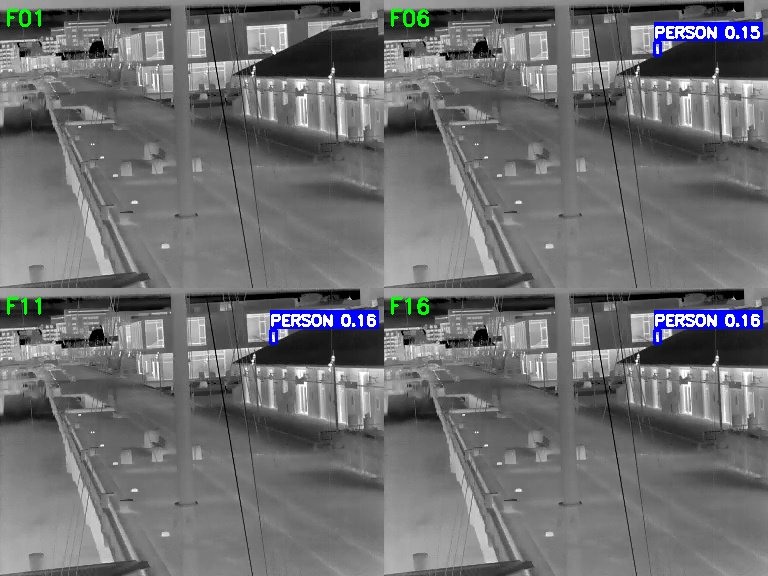


──────────────────────────────────────────────────
  #7 | 20210115/clip_5_1808 | multi_frame_2 | max_conf=0.18
──────────────────────────────────────────────────


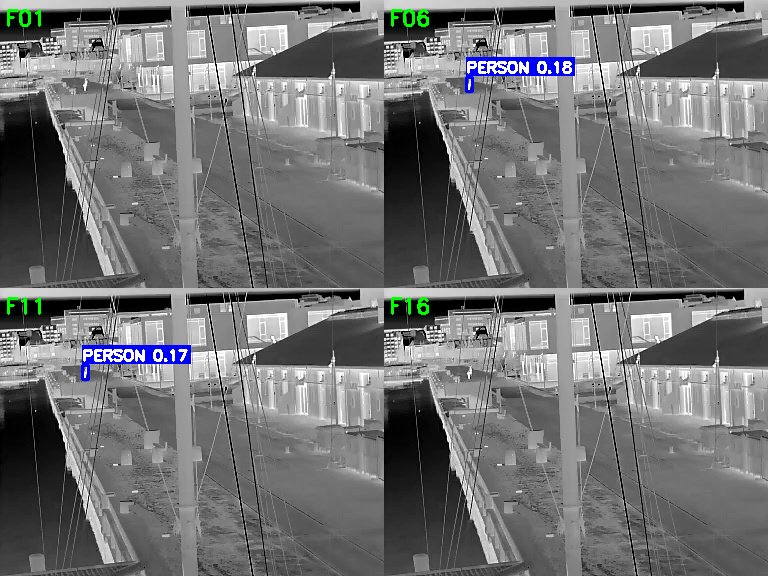



ADIM 2 — Sonuçlar Drive'a yazılıyor...

  DOĞRULAMA RAPORU v3 — DENGELİ
  Toplam süre            : 2.3 dakika
  Tarama süresi          : 1.0 dakika
  Toplam klip            : 2188
  Temiz klip             : 2181
  Şüpheli klip           : 7
  Tek düşük conf yoksay  : 20
  Şüpheli oranı          : %0.3

  Görseller              : /content/drive/MyDrive/archive/pure_bg_verification_v3/suspect_clips
  JSON rapor             : /content/drive/MyDrive/archive/pure_bg_verification_v3/verification_report_v3.json

  ⚠️  7 şüpheli — yukarıdaki görselleri incele.
     Gerçek insanlar varsa o klipleri sil.

Şüpheli liste:
------------------------------------------------------------
  20210115/clip_5_1808 | multi_frame_2 | conf=0.18 | frames=2
  20210120/clip_7_0272 | multi_frame_3 | conf=0.22 | frames=3
  20210124/clip_16_1848 | multi_frame_4 | conf=0.23 | frames=4
  20210218/clip_0_2632 | multi_frame_4 | conf=0.20 | frames=4
  20210223/clip_4_2816 | multi_frame_4 | conf=0.19 | frames=4
  202103

In [ ]:
"""
PURE BACKGROUND DOĞRULAMA v3 — DENGELİ
========================================
Google Colab — A100 80GB GPU, 167GB RAM

STRATEJİ:
  - Termal blob filtresi YOK (bu sahnede sadece false positive üretiyordu)
  - YOLO conf=0.15 (çıkarma pipeline'ıyla aynı, dengeli)
  - ÇOKLU FRAME TUTARLILIK KURALI:
      → 4 sample frame'den 2+'sinde PERSON → ŞÜPHELİ
      → 1 frame'de conf≥0.30 → ŞÜPHELİ (yüksek güvenli tek tespit)
      → 1 frame'de conf<0.30 → TEMİZ (false positive)
      → 0 frame → TEMİZ

ÇIKTI:
  - Eski suspect klasörü silinir, yenisi oluşur
  - En şüpheli 10 klibin görseli konsola basılır
  - JSON rapor + grid görseller Drive'a yazılır
"""

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 0 — KURULUM
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess
subprocess.run(['pip', 'install', 'ultralytics', '-q'])

from google.colab import drive
drive.mount('/content/drive')

import cv2, os, shutil, time, json, gc
import numpy as np
from pathlib import Path
from ultralytics import YOLO
from IPython.display import display, Image as IPImage
import io

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 1 — KONFİGÜRASYON
# ═══════════════════════════════════════════════════════════════════════════════

PURE_BG_DRIVE  = Path('/content/drive/MyDrive/archive/Data_Subset_Autoencoders_Anomaly_Detectors/training/pure_background')

# Eski verification klasörlerini temizle, yenisini oluştur
OLD_VERIFY_V1  = Path('/content/drive/MyDrive/archive/pure_bg_verification')
OLD_VERIFY_V2  = Path('/content/drive/MyDrive/archive/pure_bg_verification_v2')
OUTPUT_DRIVE   = Path('/content/drive/MyDrive/archive/pure_bg_verification_v3')

LOCAL_COPY     = Path('/content/local_pure_bg')
SUSPECT_LOCAL  = Path('/content/suspect_clips_local')

SAMPLE_INDICES = [0, 5, 10, 15]

# YOLO
YOLO_MODEL     = 'yolov8x.pt'
YOLO_CONF      = 0.15
YOLO_BATCH     = 512

# Karar kuralı
MIN_FRAMES_FOR_SUSPECT = 2
HIGH_CONF_THRESHOLD    = 0.30

JPEG_QUALITY = 90

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 2 — ESKİ SUSPECT KLASÖRLERİNİ TEMİZLE
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("ESKİ DOĞRULAMA ÇIKTILARI TEMİZLENİYOR...")
print("=" * 65)

for old_dir in [OLD_VERIFY_V1, OLD_VERIFY_V2, OUTPUT_DRIVE]:
    if old_dir.exists():
        shutil.rmtree(str(old_dir))
        print(f"  Silindi: {old_dir.name}")

OUTPUT_DRIVE.mkdir(parents=True, exist_ok=True)
print()

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 3 — DRIVE → LOCAL SSD
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("ADIM 0 — Drive → Local SSD")
print("=" * 65)

if LOCAL_COPY.exists():
    shutil.rmtree(str(LOCAL_COPY))
if SUSPECT_LOCAL.exists():
    shutil.rmtree(str(SUSPECT_LOCAL))
SUSPECT_LOCAL.mkdir(parents=True, exist_ok=True)

t_copy_start = time.time()
print("Kopyalanıyor...", flush=True)
shutil.copytree(str(PURE_BG_DRIVE), str(LOCAL_COPY))

n_days = sum(1 for d in LOCAL_COPY.iterdir() if d.is_dir())
n_clips = sum(1 for d in LOCAL_COPY.iterdir() if d.is_dir() for c in d.iterdir() if c.is_dir())
t_copy = time.time() - t_copy_start
print(f"Kopyalandı: {n_days} gün, {n_clips} klip | {t_copy:.0f}s\n")

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 4 — YOLO
# ═══════════════════════════════════════════════════════════════════════════════

print("YOLOv8x yükleniyor...")
model = YOLO(YOLO_MODEL)
model.to('cuda')
print("Hazır.\n")

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 5 — FONKSİYONLAR
# ═══════════════════════════════════════════════════════════════════════════════

def load_clip_samples(clip_dir: Path) -> list:
    jpg_files = sorted(clip_dir.glob('frame_*.jpg'))
    if not jpg_files:
        return []
    samples = []
    for idx in SAMPLE_INDICES:
        if idx < len(jpg_files):
            frame = cv2.imread(str(jpg_files[idx]))
            if frame is not None:
                samples.append((idx, frame))
    return samples


def batch_yolo_person(frames: list) -> list:
    if not frames:
        return []
    all_results = []
    for bs in range(0, len(frames), YOLO_BATCH):
        batch = frames[bs : bs + YOLO_BATCH]
        results = model(
            batch, classes=[0], conf=YOLO_CONF,
            verbose=False, half=True, device='cuda',
        )
        for r in results:
            dets = []
            for box in r.boxes:
                dets.append({
                    'conf': float(box.conf[0]),
                    'bbox': box.xyxy[0].cpu().numpy().tolist(),
                })
            all_results.append(dets)
    return all_results


def evaluate_clip(frame_detections: dict) -> dict:
    """
    Çoklu frame tutarlılık kuralı.

    Kural:
      - 2+ frame'de person → ŞÜPHELİ (tutarlı tespit)
      - 1 frame'de conf≥0.30 → ŞÜPHELİ (yüksek güvenli)
      - 1 frame'de conf<0.30 → TEMİZ (false positive)
      - 0 frame → TEMİZ
    """
    frames_with_person = {fi: dets for fi, dets in frame_detections.items() if dets}
    n_person_frames = len(frames_with_person)

    if n_person_frames == 0:
        return {'is_suspect': False, 'reason': 'clean', 'n_frames': 0, 'max_conf': 0.0, 'detections': {}}

    max_conf = max(d['conf'] for dets in frames_with_person.values() for d in dets)

    if n_person_frames >= MIN_FRAMES_FOR_SUSPECT:
        return {
            'is_suspect': True,
            'reason': f'multi_frame_{n_person_frames}',
            'n_frames': n_person_frames,
            'max_conf': max_conf,
            'detections': frames_with_person,
        }
    elif max_conf >= HIGH_CONF_THRESHOLD:
        return {
            'is_suspect': True,
            'reason': f'high_conf_{max_conf:.2f}',
            'n_frames': n_person_frames,
            'max_conf': max_conf,
            'detections': frames_with_person,
        }
    else:
        return {
            'is_suspect': False,
            'reason': f'single_low_conf_{max_conf:.2f}',
            'n_frames': n_person_frames,
            'max_conf': max_conf,
            'detections': {},
        }


def create_suspect_grid(samples: list, detections: dict) -> np.ndarray:
    """
    4 frame'i 2x2 grid olarak oluşturur.
    Person tespitlerini kırmızı kutuyla işaretler.
    Returns: grid numpy array
    """
    frames_vis = []
    for frame_idx, frame_bgr in samples:
        vis = frame_bgr.copy()

        if frame_idx in detections:
            for det in detections[frame_idx]:
                x1, y1, x2, y2 = [int(v) for v in det['bbox']]
                conf = det['conf']
                cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 0, 255), 2)
                label = f"PERSON {conf:.2f}"
                # Arka plan kutusu
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)
                cv2.rectangle(vis, (x1, max(y1 - th - 8, 0)), (x1 + tw, max(y1 - 2, th + 6)), (0, 0, 255), -1)
                cv2.putText(vis, label, (x1, max(y1 - 5, 15)),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

        # Frame numarası
        cv2.putText(vis, f"F{frame_idx+1:02d}", (5, 25),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        frames_vis.append(vis)

    if len(frames_vis) >= 4:
        row1 = np.hstack(frames_vis[:2])
        row2 = np.hstack(frames_vis[2:4])
        grid = np.vstack([row1, row2])
    elif len(frames_vis) >= 2:
        grid = np.hstack(frames_vis[:2])
    elif len(frames_vis) == 1:
        grid = frames_vis[0]
    else:
        return None

    return grid


def display_grid_in_console(grid: np.ndarray, title: str):
    """Grid görselini Colab konsolunda gösterir."""
    # BGR → RGB
    grid_rgb = cv2.cvtColor(grid, cv2.COLOR_BGR2RGB)
    # Encode to JPEG bytes
    _, buf = cv2.imencode('.jpg', grid_rgb, [cv2.IMWRITE_JPEG_QUALITY, 85])
    print(f"\n{'─'*50}")
    print(f"  {title}")
    print(f"{'─'*50}")
    display(IPImage(data=buf.tobytes()))


# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 6 — ANA TARAMA
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("ADIM 1 — YOLO Tarama + Çoklu Frame Tutarlılık")
print(f"  YOLO conf={YOLO_CONF} | Min frames={MIN_FRAMES_FOR_SUSPECT}")
print(f"  Yüksek güven eşiği={HIGH_CONF_THRESHOLD}")
print("=" * 65)

day_dirs = sorted([d for d in LOCAL_COPY.iterdir() if d.is_dir()])
total_clips = sum(1 for d in day_dirs for c in d.iterdir() if c.is_dir())
print(f"Toplam: {total_clips} klip\n")

stats = {
    'total_clips': total_clips,
    'clean_clips': 0,
    'suspect_clips': 0,
    'ignored_single_low': 0,
    'suspects': [],
}

# Şüpheli klipleri skorla birlikte tut (en şüphelileri göstermek için)
suspect_grids = []  # [(score, title, grid, info)]

t_scan = time.time()
processed = 0

for day_idx, day_dir in enumerate(day_dirs):
    clip_dirs = sorted([c for c in day_dir.iterdir() if c.is_dir()])
    if not clip_dirs:
        continue

    # Günün tüm sample frame'lerini topla
    clip_data = []
    all_frames = []
    frame_map = []

    for clip_dir in clip_dirs:
        samples = load_clip_samples(clip_dir)
        clip_data.append((clip_dir, samples))
        for fi, fbgr in samples:
            frame_map.append((len(clip_data) - 1, fi))
            all_frames.append(fbgr)

    if not all_frames:
        continue

    # Toplu YOLO
    yolo_results = batch_yolo_person(all_frames)

    # Klip bazında değerlendir
    for clip_idx, (clip_dir, samples) in enumerate(clip_data):
        frame_dets = {}

        for gpos, (ci, fi) in enumerate(frame_map):
            if ci != clip_idx:
                continue
            if gpos < len(yolo_results):
                frame_dets[fi] = yolo_results[gpos]

        result = evaluate_clip(frame_dets)

        if result['is_suspect']:
            stats['suspect_clips'] += 1

            # Grid oluştur
            grid = create_suspect_grid(samples, result['detections'])

            # Skor: frame sayısı × max confidence (sıralama için)
            score = result['n_frames'] * result['max_conf']
            title = f"{day_dir.name}/{clip_dir.name} | {result['reason']} | max_conf={result['max_conf']:.2f}"

            if grid is not None:
                # Local'e kaydet
                out_path = SUSPECT_LOCAL / f"{day_dir.name}__{clip_dir.name}.jpg"
                cv2.imwrite(str(out_path), grid, [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])

                # En şüpheliler listesine ekle
                suspect_grids.append((score, title, grid, {
                    'day': day_dir.name,
                    'clip': clip_dir.name,
                    'reason': result['reason'],
                    'n_frames': result['n_frames'],
                    'max_conf': result['max_conf'],
                }))

            stats['suspects'].append({
                'day': day_dir.name,
                'clip': clip_dir.name,
                'reason': result['reason'],
                'n_frames': result['n_frames'],
                'max_conf': result['max_conf'],
            })
        else:
            stats['clean_clips'] += 1
            if result['reason'].startswith('single_low'):
                stats['ignored_single_low'] += 1

    processed += len(clip_dirs)
    elapsed = time.time() - t_scan
    rate = processed / elapsed if elapsed > 0 else 0
    eta = (total_clips - processed) / rate if rate > 0 else 0

    print(f"[{day_dir.name}] {len(clip_dirs)} klip | "
          f"Şüpheli: {stats['suspect_clips']} | "
          f"Yoksayılan: {stats['ignored_single_low']} | "
          f"ETA:{eta/60:.1f}dk", flush=True)

    del all_frames, yolo_results, frame_map, clip_data
    gc.collect()

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 7 — EN ŞÜPHELİ 10 KLİBİ KONSOLA GÖSTER
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("EN ŞÜPHELİ 10 KLİP (skora göre sıralı)")
print("=" * 65)

# Skora göre azalan sırala
suspect_grids.sort(key=lambda x: x[0], reverse=True)

if suspect_grids:
    for i, (score, title, grid, info) in enumerate(suspect_grids[:10]):
        display_grid_in_console(grid, f"#{i+1} | {title}")
else:
    print("\n  Hiç şüpheli klip bulunamadı! ✅")

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 8 — SONUÇLARI DRIVE'A YAZ
# ═══════════════════════════════════════════════════════════════════════════════

print("\n\nADIM 2 — Sonuçlar Drive'a yazılıyor...", flush=True)

# Suspect görselleri kopyala
suspect_drive = OUTPUT_DRIVE / 'suspect_clips'
if SUSPECT_LOCAL.exists() and any(SUSPECT_LOCAL.iterdir()):
    shutil.copytree(str(SUSPECT_LOCAL), str(suspect_drive))
else:
    suspect_drive.mkdir(parents=True, exist_ok=True)

# JSON rapor
total_time = time.time() - t_copy_start
stats['total_time_minutes'] = round(total_time / 60, 1)
stats['scan_time_minutes'] = round((time.time() - t_scan) / 60, 1)
stats['config'] = {
    'yolo_model': YOLO_MODEL,
    'yolo_conf': YOLO_CONF,
    'min_frames_for_suspect': MIN_FRAMES_FOR_SUSPECT,
    'high_conf_threshold': HIGH_CONF_THRESHOLD,
    'sample_indices': SAMPLE_INDICES,
}

report_path = OUTPUT_DRIVE / 'verification_report_v3.json'
with open(str(report_path), 'w', encoding='utf-8') as f:
    json.dump(stats, f, indent=2, ensure_ascii=False)

# Local temizlik
shutil.rmtree(str(LOCAL_COPY), ignore_errors=True)
shutil.rmtree(str(SUSPECT_LOCAL), ignore_errors=True)

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 9 — RAPOR
# ═══════════════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("  DOĞRULAMA RAPORU v3 — DENGELİ")
print("=" * 65)
print(f"  Toplam süre            : {total_time/60:.1f} dakika")
print(f"  Tarama süresi          : {stats['scan_time_minutes']:.1f} dakika")
print(f"  Toplam klip            : {stats['total_clips']}")
print(f"  Temiz klip             : {stats['clean_clips']}")
print(f"  Şüpheli klip           : {stats['suspect_clips']}")
print(f"  Tek düşük conf yoksay  : {stats['ignored_single_low']}")

if stats['total_clips'] > 0:
    sr = stats['suspect_clips'] / stats['total_clips'] * 100
    print(f"  Şüpheli oranı          : %{sr:.1f}")

print(f"\n  Görseller              : {suspect_drive}")
print(f"  JSON rapor             : {report_path}")
print()

if stats['suspect_clips'] == 0:
    print("  ✅ TÜM KLİPLER TEMİZ! Pure background onaylandı.")
elif stats['suspect_clips'] <= 5:
    print(f"  ✅ Sadece {stats['suspect_clips']} şüpheli — yukarıdaki görselleri incele.")
    print("     Muhtemelen false positive, ama kontrol et.")
elif stats['suspect_clips'] <= 20:
    print(f"  ⚠️  {stats['suspect_clips']} şüpheli — yukarıdaki görselleri incele.")
    print("     Gerçek insanlar varsa o klipleri sil.")
else:
    print(f"  ❌ {stats['suspect_clips']} şüpheli — ciddi temizlik gerekebilir.")

print()
print("Şüpheli liste:")
print("-" * 60)
for s in stats['suspects']:
    print(f"  {s['day']}/{s['clip']} | {s['reason']} | conf={s['max_conf']:.2f} | frames={s['n_frames']}")
print("=" * 65)
print("\nYukarıdaki görselleri incele → sonucu Claude'a bildir.")

In [ ]:
"""286 insanlı klibi pure_background'dan sil."""

from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

P = Path('/content/drive/MyDrive/archive/Data_Subset_Autoencoders_Anomaly_Detectors/training/pure_background')

TO_DELETE = [
"20210108/clip_2_0712","20210108/clip_3_0624","20210109/clip_11_2960",
"20210109/clip_9_0152","20210110/clip_5_0408","20210110/clip_5_0920",
"20210111/clip_12_2296","20210111/clip_7_0856","20210111/clip_9_2096",
"20210112/clip_0_0144","20210112/clip_0_0280","20210112/clip_0_0376",
"20210112/clip_0_0456","20210112/clip_0_0584","20210112/clip_0_0656",
"20210112/clip_0_0736","20210112/clip_0_0832","20210112/clip_0_0928",
"20210112/clip_0_1000","20210112/clip_0_1120","20210112/clip_0_1368",
"20210112/clip_0_1496","20210112/clip_0_1568","20210112/clip_0_171",
"20210113/clip_2_0464","20210113/clip_3_0224","20210113/clip_3_1136",
"20210113/clip_4_1512","20210115/clip_2_1008","20210115/clip_2_2168",
"20210115/clip_2_2688","20210116/clip_8_1920","20210116/clip_9_1384",
"20210117/clip_1_1072","20210117/clip_2_1696","20210117/clip_3_0240",
"20210119/clip_0_0000","20210119/clip_0_0512","20210119/clip_0_0888",
"20210119/clip_0_1264","20210119/clip_0_1672","20210119/clip_0_2184",
"20210119/clip_0_2560","20210119/clip_0_2928","20210120/clip_3_0896",
"20210120/clip_3_1752","20210120/clip_4_1432","20210122/clip_4_0384",
"20210122/clip_4_1576","20210122/clip_4_2872","20210122/clip_5_1016",
"20210122/clip_5_1616","20210122/clip_5_2224","20210122/clip_6_1568",
"20210122/clip_6_2328","20210130/clip_3_0208","20210130/clip_3_0896",
"20210130/clip_3_1544","20210130/clip_3_2288","20210201/clip_2_1056",
"20210201/clip_2_2248","20210201/clip_5_1496","20210202/clip_1_0432",
"20210216/clip_12_0384","20210216/clip_12_1032","20210216/clip_12_2216",
"20210216/clip_12_2928","20210216/clip_13_0984","20210216/clip_14_0768",
"20210216/clip_14_1488","20210216/clip_15_1224","20210216/clip_15_1880",
"20210216/clip_5_2408","20210216/clip_6_2840","20210218/clip_11_1672",
"20210218/clip_3_0424","20210218/clip_7_1640","20210227/clip_0_0000",
"20210227/clip_0_0080","20210227/clip_0_0176","20210227/clip_0_2024",
"20210227/clip_0_2944","20210227/clip_1_0360","20210227/clip_1_1488",
"20210227/clip_1_2192","20210227/clip_1_2304","20210227/clip_1_2384",
"20210227/clip_1_2576","20210227/clip_1_2656","20210227/clip_1_2736",
"20210227/clip_1_2840","20210227/clip_1_2920","20210227/clip_2_0096",
"20210227/clip_2_0344","20210227/clip_2_0432","20210227/clip_2_1208",
"20210301/clip_0_0000","20210301/clip_0_1288","20210301/clip_0_1592",
"20210301/clip_0_2352","20210301/clip_1_0544","20210301/clip_1_1040",
"20210301/clip_2_1408","20210301/clip_2_2480","20210301/clip_3_1280",
"20210301/clip_4_0680","20210301/clip_4_1472","20210301/clip_4_1928",
"20210301/clip_5_1064","20210301/clip_5_1408","20210301/clip_5_1928",
"20210301/clip_5_2968","20210302/clip_0_1384","20210302/clip_0_2232",
"20210302/clip_0_2872","20210302/clip_10_1784","20210302/clip_11_1712",
"20210302/clip_1_1072","20210302/clip_1_1664","20210302/clip_2_1024",
"20210302/clip_3_0192","20210302/clip_4_0424","20210302/clip_6_0360",
"20210302/clip_7_1272","20210305/clip_5_2040","20210305/clip_8_0120",
"20210306/clip_1_0928","20210306/clip_1_1464","20210306/clip_1_1824",
"20210306/clip_1_2264","20210306/clip_4_0144","20210306/clip_5_0888",
"20210307/clip_0_0000","20210307/clip_11_0648","20210311/clip_10_1864",
"20210311/clip_1_0728","20210311/clip_2_1720","20210311/clip_3_0440",
"20210311/clip_3_2304","20210311/clip_9_0240","20210313/clip_0_0000",
"20210313/clip_0_0536","20210313/clip_0_1104","20210313/clip_0_1648",
"20210313/clip_0_2192","20210313/clip_0_2736","20210313/clip_3_0368",
"20210313/clip_3_0912","20210313/clip_3_1456","20210313/clip_3_2000",
"20210313/clip_3_2544","20210313/clip_4_0208","20210313/clip_4_1360",
"20210313/clip_8_0120","20210313/clip_8_0744","20210313/clip_8_1312",
"20210313/clip_9_0616","20210313/clip_9_1736","20210313/clip_9_2344",
"20210314/clip_0_0376","20210314/clip_0_1160","20210314/clip_0_1912",
"20210314/clip_0_2568","20210314/clip_4_0728","20210314/clip_4_1624",
"20210314/clip_4_2400","20210314/clip_7_0504","20210314/clip_7_2768",
"20210314/clip_8_0528","20210314/clip_8_1536","20210317/clip_0_0080",
"20210317/clip_0_1304","20210317/clip_1_0184","20210320/clip_13_1448",
"20210320/clip_3_0424","20210320/clip_4_0608","20210320/clip_4_1992",
"20210320/clip_5_0944","20210320/clip_6_0112","20210320/clip_6_1816",
"20210320/clip_7_0448","20210320/clip_8_0232","20210321/clip_0_0000",
"20210321/clip_0_0064","20210321/clip_0_0128","20210321/clip_0_0192",
"20210321/clip_0_0256","20210321/clip_0_0320","20210321/clip_0_0384",
"20210321/clip_0_0448","20210321/clip_0_0552","20210321/clip_0_0736",
"20210321/clip_0_0888","20210321/clip_0_0952","20210323/clip_4_2176",
"20210323/clip_5_2144","20210323/clip_5_2816","20210323/clip_7_0200",
"20210323/clip_7_1160","20210323/clip_9_2448","20210324/clip_0_0024",
"20210324/clip_0_0208","20210324/clip_0_0312","20210324/clip_0_0416",
"20210324/clip_0_0512","20210324/clip_0_0616","20210324/clip_0_0880",
"20210324/clip_0_0976","20210324/clip_1_1568","20210324/clip_3_0096",
"20210324/clip_3_0720","20210324/clip_3_0920","20210324/clip_3_1056",
"20210324/clip_3_1208","20210324/clip_3_1312","20210324/clip_3_1416",
"20210324/clip_4_0024","20210324/clip_4_0280","20210324/clip_4_0720",
"20210324/clip_4_1240","20210324/clip_4_1928","20210324/clip_4_2272",
"20210324/clip_4_2432","20210324/clip_4_2744","20210324/clip_4_2888",
"20210325/clip_0_0304","20210326/clip_1_0248","20210326/clip_1_1016",
"20210326/clip_1_2088","20210326/clip_1_2704","20210326/clip_2_2056",
"20210326/clip_2_2736","20210326/clip_3_0808","20210326/clip_3_1848",
"20210326/clip_3_2696","20210326/clip_4_0472","20210326/clip_4_1336",
"20210326/clip_5_0480","20210326/clip_5_1040","20210326/clip_5_1608",
"20210326/clip_5_2168","20210326/clip_5_2728","20210326/clip_6_0304",
"20210326/clip_6_0864","20210326/clip_6_1424","20210326/clip_6_1984",
"20210327/clip_0_0216","20210327/clip_0_0432","20210327/clip_0_0648",
"20210327/clip_0_0864","20210327/clip_0_1080","20210327/clip_0_1488",
"20210327/clip_0_1704","20210327/clip_1_0136","20210327/clip_1_0400",
"20210327/clip_1_0640","20210327/clip_1_2000","20210327/clip_1_2216",
"20210327/clip_1_2512","20210327/clip_2_0120","20210327/clip_2_0336",
"20210328/clip_2_2488","20210328/clip_3_0824","20210328/clip_3_2192",
"20210328/clip_3_2920","20210328/clip_4_0656","20210328/clip_4_2520",
"20210328/clip_5_1160","20210328/clip_5_2648","20210328/clip_6_2432",
"20210328/clip_7_2312","20210329/clip_10_2416","20210329/clip_12_0560",
"20210329/clip_13_1808","20210329/clip_19_2376","20210329/clip_22_0840",
"20210329/clip_22_2624","20210329/clip_5_2792","20210329/clip_8_0232",
"20210330/clip_4_1904","20210330/clip_5_1152","20210330/clip_6_0816",
"20210330/clip_6_2224","20210331/clip_2_2040","20210331/clip_2_2240",
"20210331/clip_2_2440",
]

d = e = 0
for rel in TO_DELETE:
    cp = P / rel
    if cp.exists():
        shutil.rmtree(str(cp))
        d += 1
    else:
        e += 1
        print(f"✗ {rel}")

# Boş klasörleri temizle
for dd in P.iterdir():
    if dd.is_dir() and not any(dd.iterdir()):
        dd.rmdir()

r = sum(1 for dd in P.iterdir() if dd.is_dir() for c in dd.iterdir() if c.is_dir())
print(f"\nSilinen: {d} | Bulunamayan: {e} | Kalan: {r}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✗ 20210112/clip_0_171

Silinen: 285 | Bulunamayan: 1 | Kalan: 1903


In [ ]:
"""
PURE BACKGROUND — MANUEL İNCELEME
====================================
2188 klibin hepsinden ortadaki frame'i gösterir.
Her sayfada 20 klip (4x5 grid).
Her sayfanın üstünde metin olarak klip isimleri (kopyalanabilir).
"""

from google.colab import drive
drive.mount('/content/drive')

import cv2, shutil
import numpy as np
from pathlib import Path
from IPython.display import display, Image as IPImage

PURE_BG = Path('/content/drive/MyDrive/archive/Data_Subset_Autoencoders_Anomaly_Detectors/training/pure_background')
LOCAL = Path('/content/local_pb_review')

if LOCAL.exists():
    shutil.rmtree(str(LOCAL))
print("Kopyalanıyor...", flush=True)
shutil.copytree(str(PURE_BG), str(LOCAL))
print("Hazır.\n")

# Tüm klipleri topla
all_clips = []
for day_dir in sorted(LOCAL.iterdir()):
    if not day_dir.is_dir(): continue
    for clip_dir in sorted(day_dir.iterdir()):
        if not clip_dir.is_dir(): continue
        all_clips.append({'day': day_dir.name, 'clip': clip_dir.name, 'path': clip_dir})

print(f"Toplam klip: {len(all_clips)}\n")

COLS = 4; ROWS = 5; PER_PAGE = COLS * ROWS
THUMB_W = 280; THUMB_H = 210
total_pages = (len(all_clips) + PER_PAGE - 1) // PER_PAGE

for page in range(total_pages):
    start = page * PER_PAGE
    end = min(start + PER_PAGE, len(all_clips))
    page_clips = all_clips[start:end]

    # Metin listesi
    print(f"\n{'━'*65}")
    print(f"SAYFA {page+1}/{total_pages} | #{start}-#{end-1}")
    print(f"{'━'*65}")
    for idx, c in enumerate(page_clips):
        gi = start + idx
        r = idx // COLS + 1
        co = idx % COLS + 1
        print(f"  [{r},{co}] #{gi} {c['day']}/{c['clip']}")
    print(f"{'━'*65}")

    # Grid
    grid_rows = []
    for row in range(ROWS):
        row_imgs = []
        for col in range(COLS):
            idx = row * COLS + col
            if idx >= len(page_clips):
                row_imgs.append(np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8))
                continue

            c = page_clips[idx]
            gi = start + idx

            fp = c['path'] / 'frame_008.jpg'
            if not fp.exists():
                jpgs = sorted(c['path'].glob('frame_*.jpg'))
                fp = jpgs[len(jpgs)//2] if jpgs else None

            if fp and fp.exists():
                img = cv2.imread(str(fp))
                img = cv2.resize(img, (THUMB_W, THUMB_H)) if img is not None else np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8)
            else:
                img = np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8)

            r = idx // COLS + 1
            co = idx % COLS + 1
            cv2.rectangle(img, (0, 0), (THUMB_W, 25), (0, 0, 0), -1)
            cv2.putText(img, f"[{r},{co}] #{gi} {c['day'][-4:]}/{c['clip'][-8:]}", (3, 18),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
            cv2.rectangle(img, (0, 0), (THUMB_W-1, THUMB_H-1), (0, 200, 0), 1)
            row_imgs.append(img)
        grid_rows.append(np.hstack(row_imgs))

    grid = np.vstack(grid_rows)
    grid_rgb = cv2.cvtColor(grid, cv2.COLOR_BGR2RGB)
    _, buf = cv2.imencode('.jpg', grid_rgb, [cv2.IMWRITE_JPEG_QUALITY, 80])
    display(IPImage(data=buf.tobytes()))

shutil.rmtree(str(LOCAL), ignore_errors=True)

print(f"\n{'='*65}")
print("İnceleme tamamlandı.")
print("Yanlış klipler varsa isimlerini Claude'a yaz.")
print(f"{'='*65}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from pathlib import Path
for p in sorted(Path('/content').iterdir()):
    print(p)

/content/.config
/content/drive
/content/pure_bg_buffer
/content/sample_data
/content/yolov8x.pt


In [ ]:
"""
TESTING FINAL EXTRACTION PIPELINE
===================================
Google Colab — A100 80GB GPU, 167GB RAM

AMAÇ:
  LTD Dataset'in yaz aylarından test seti oluştur.
  CR-AE kışla eğitildi → yazla test edilecek (drift evaluation).
  Mevcut testing_final tamamen silinip sıfırdan oluşturulur.

KARAR MEKANİZMASI:
  Termal YOLO (pitangent-ds/YOLOv8-human-detection-thermal)
  Tüm 16 frame taranır, toplu batch inference.

  NORMAL  = 0/16 frame'de insan tespiti
  ANOMALİ = 3+/16 frame'de insan tespiti
  BELİRSİZ = 1-2/16 frame → ATLANIR

HEDEF:
  4 ay: 202005, 202006, 202008, 202104
  Her ay: 98 normal + 42 anomali = 140 klip (%70/%30)
  Toplam: 560 klip
  Günlere eşit dağılım zorunlu (temporal çeşitlilik)

KLASÖR YAPISI:
  testing_final/YYYYMMDD/normal/clip_V_SSSS/frame_001.jpg...016.jpg
  testing_final/YYYYMMDD/anomaly/clip_V_SSSS/frame_001.jpg...016.jpg + detections.txt

OPTİMİZASYON:
  - Toplu batch YOLO inference (video bazında tüm frame'ler tek seferde)
  - Local buffer → periyodik Drive flush
  - A100 80GB GPU + 167GB RAM tam kullanım
"""

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 0 — KURULUM
# ═══════════════════════════════════════════════════════════════════════════════

import subprocess
subprocess.run(['pip', 'install', 'ultralytics', 'huggingface_hub', '-q'])

from google.colab import drive
drive.mount('/content/drive')

import cv2, os, shutil, time, json, gc
import numpy as np
from pathlib import Path
from ultralytics import YOLO
from huggingface_hub import hf_hub_download
from collections import defaultdict

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 1 — KONFİGÜRASYON
# ═══════════════════════════════════════════════════════════════════════════════

# --- Yollar ---
LTD_CLIPS       = Path('/content/drive/MyDrive/archive/LTD Dataset/LTD Dataset/Video Clips')
TESTING_DRIVE   = Path('/content/drive/MyDrive/archive/Data_Subset_Autoencoders_Anomaly_Detectors/testing/testing_final')
LOCAL_BUFFER    = Path('/content/testing_final_buffer')
LOG_FILE        = Path('/content/drive/MyDrive/archive/testing_final_extraction_log.json')

# --- Hedef aylar ve kotalar ---
TARGET_MONTHS = {
    '202005': {'normal': 98, 'anomaly': 42},
    '202006': {'normal': 98, 'anomaly': 42},
    '202008': {'normal': 98, 'anomaly': 42},
    '202104': {'normal': 98, 'anomaly': 42},
}

# --- Klip parametreleri ---
FRAMES_PER_CLIP = 16
WINDOW_STEP     = 8

# --- Termal YOLO ---
YOLO_CONF       = 0.15
YOLO_BATCH      = 512      # A100 80GB → büyük batch

# --- Çoklu frame tutarlılık ---
MIN_FRAMES_ANOMALY = 3     # 3+ frame'de tespit → anomali
MAX_FRAMES_NORMAL  = 0     # 0 frame tespit → normal
# 1-2 frame → belirsiz → atla

# --- Günlere dağılım ---
# Her ayda ~25-30 gün var
# 98 normal / 25 gün ≈ 4 normal/gün
# 42 anomali / 25 gün ≈ 2 anomali/gün
MAX_NORMAL_PER_DAY  = 6    # biraz yüksek tut (bazı günlerde az klip olabilir)
MAX_ANOMALY_PER_DAY = 3

# --- Diğer ---
JPEG_QUALITY        = 95
FLUSH_EVERY_N_DAYS  = 5

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 2 — MEVCUT TESTING_FINAL'I SİL
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("AŞAMA A — Mevcut testing_final siliniyor...")
print("=" * 65)

if TESTING_DRIVE.exists():
    existing = sum(1 for _ in TESTING_DRIVE.rglob('frame_001.jpg'))
    print(f"Mevcut klip sayısı (tahmini): {existing}")
    shutil.rmtree(str(TESTING_DRIVE))
    print("Tamamen silindi ✓")
else:
    print("Zaten yok.")

TESTING_DRIVE.mkdir(parents=True, exist_ok=True)

if LOCAL_BUFFER.exists():
    shutil.rmtree(str(LOCAL_BUFFER))
LOCAL_BUFFER.mkdir(parents=True, exist_ok=True)
print()

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 3 — TERMAL YOLO MODELİ
# ═══════════════════════════════════════════════════════════════════════════════

print("Termal YOLO modeli indiriliyor...")
model_path = hf_hub_download(
    repo_id="pitangent-ds/YOLOv8-human-detection-thermal",
    filename="model.pt"
)
thermal_model = YOLO(model_path)
thermal_model.to('cuda')
print("Termal YOLO hazır.\n")

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 4 — FONKSİYONLAR
# ═══════════════════════════════════════════════════════════════════════════════

def batch_thermal_person_map(all_frames: list) -> list:
    """
    Tüm frame'leri toplu termal YOLO'ya gönderir.
    Her frame için tespit listesi döner.
    """
    n = len(all_frames)
    results_map = [[] for _ in range(n)]

    for batch_start in range(0, n, YOLO_BATCH):
        batch_end = min(batch_start + YOLO_BATCH, n)
        batch = all_frames[batch_start:batch_end]

        results = thermal_model(
            batch,
            conf=YOLO_CONF,
            verbose=False,
            half=True,
            device='cuda',
        )

        for i, r in enumerate(results):
            dets = []
            for box in r.boxes:
                dets.append({
                    'conf': float(box.conf[0]),
                    'bbox': box.xyxy[0].cpu().numpy().tolist(),
                })
            results_map[batch_start + i] = dets

    return results_map


def classify_window(person_map_window: list) -> tuple:
    """
    16 frame'lik penceredeki tespit sonuçlarını değerlendirir.

    Returns:
        (label, n_person_frames, detections_dict)
        label: 'normal', 'anomaly', 'uncertain'
    """
    detections = {}
    n_person_frames = 0

    for i, dets in enumerate(person_map_window):
        if dets:
            n_person_frames += 1
            detections[i] = dets

    if n_person_frames == 0:
        return 'normal', 0, {}
    elif n_person_frames >= MIN_FRAMES_ANOMALY:
        return 'anomaly', n_person_frames, detections
    else:
        return 'uncertain', n_person_frames, detections


def process_video(video_path: Path, video_idx: int):
    """
    Bir videoyu işler: tüm frame'leri oku → toplu YOLO → pencere bazında sınıfla.

    Returns:
        normals: [(clip_name, frames)]
        anomalies: [(clip_name, frames, detections)]
        stats: dict
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return [], [], {'windows': 0, 'normal': 0, 'anomaly': 0, 'uncertain': 0}

    all_frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        all_frames.append(frame)
    cap.release()

    total = len(all_frames)
    if total < FRAMES_PER_CLIP:
        return [], [], {'windows': 0, 'normal': 0, 'anomaly': 0, 'uncertain': 0}

    # Toplu YOLO — tüm frame'ler tek seferde
    person_map = batch_thermal_person_map(all_frames)

    normals = []
    anomalies = []
    n_windows = 0
    n_normal = 0
    n_anomaly = 0
    n_uncertain = 0

    for start in range(0, total - FRAMES_PER_CLIP + 1, WINDOW_STEP):
        n_windows += 1
        end = start + FRAMES_PER_CLIP

        window_map = person_map[start:end]
        label, n_pf, detections = classify_window(window_map)

        window_frames = all_frames[start:end]

        if label == 'normal':
            n_normal += 1
            clip_name = f"clip_{video_idx}_{start:04d}"
            normals.append((clip_name, window_frames))

        elif label == 'anomaly':
            n_anomaly += 1
            clip_name = f"clip_{video_idx}_{start:04d}"
            anomalies.append((clip_name, window_frames, detections))

        else:
            n_uncertain += 1

    stats = {
        'windows': n_windows,
        'normal': n_normal,
        'anomaly': n_anomaly,
        'uncertain': n_uncertain,
    }

    return normals, anomalies, stats


def save_normal_clip(day_name: str, clip_name: str, frames: list):
    """Normal klibi local buffer'a kaydet."""
    clip_dir = LOCAL_BUFFER / day_name / 'normal' / clip_name
    clip_dir.mkdir(parents=True, exist_ok=True)
    for i, frame in enumerate(frames, start=1):
        cv2.imwrite(
            str(clip_dir / f'frame_{i:03d}.jpg'),
            frame, [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY]
        )


def save_anomaly_clip(day_name: str, clip_name: str, frames: list, detections: dict):
    """Anomali klibi + detections.txt kaydet."""
    clip_dir = LOCAL_BUFFER / day_name / 'anomaly' / clip_name
    clip_dir.mkdir(parents=True, exist_ok=True)

    for i, frame in enumerate(frames, start=1):
        cv2.imwrite(
            str(clip_dir / f'frame_{i:03d}.jpg'),
            frame, [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY]
        )

    # Detections dosyası
    txt_path = clip_dir / 'detections.txt'
    with open(str(txt_path), 'w') as f:
        f.write(f"# Clip: {clip_name}\n")
        f.write("# Format: frame_idx conf x1 y1 x2 y2\n")
        for frame_idx in sorted(detections.keys()):
            for det in detections[frame_idx]:
                x1, y1, x2, y2 = det['bbox']
                f.write(f"frame_{frame_idx+1:03d} {det['conf']:.4f} "
                        f"{x1:.1f} {y1:.1f} {x2:.1f} {y2:.1f}\n")


def flush_local_to_drive():
    """Local buffer → Drive."""
    copied_clips = 0

    for day_dir in sorted(LOCAL_BUFFER.iterdir()):
        if not day_dir.is_dir():
            continue

        for cat_dir in day_dir.iterdir():
            if not cat_dir.is_dir():
                continue

            for clip_dir in cat_dir.iterdir():
                if not clip_dir.is_dir():
                    continue

                dest = TESTING_DRIVE / day_dir.name / cat_dir.name / clip_dir.name
                dest.parent.mkdir(parents=True, exist_ok=True)
                if dest.exists():
                    shutil.rmtree(str(dest))
                shutil.copytree(str(clip_dir), str(dest))
                copied_clips += 1

        shutil.rmtree(str(day_dir))

    return copied_clips


# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 5 — ANA DÖNGÜ
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("AŞAMA B — Testing Final Çıkarma")
print("  Termal YOLO + Çoklu Frame Tutarlılık (3+ frame = anomali)")
print("  70% normal / 30% anomali | Günlere eşit dağılım")
print("=" * 65)

# Ayların günlerini topla
month_days = defaultdict(list)
for day_dir in sorted(LTD_CLIPS.iterdir()):
    if not day_dir.is_dir():
        continue
    for month_prefix in TARGET_MONTHS:
        if day_dir.name.startswith(month_prefix):
            month_days[month_prefix].append(day_dir)

print("\nGün sayıları:")
for m, days in sorted(month_days.items()):
    quota = TARGET_MONTHS[m]
    n_days = len(days)
    norm_per_day = quota['normal'] / n_days if n_days > 0 else 0
    anom_per_day = quota['anomaly'] / n_days if n_days > 0 else 0
    print(f"  {m}: {n_days} gün | hedef: {quota['normal']}N + {quota['anomaly']}A "
          f"| ~{norm_per_day:.1f}N/gün ~{anom_per_day:.1f}A/gün")
print()

# Global istatistikler
global_stats = {
    'start_time': time.strftime('%Y-%m-%d %H:%M:%S'),
    'config': {
        'target_months': TARGET_MONTHS,
        'frames_per_clip': FRAMES_PER_CLIP,
        'window_step': WINDOW_STEP,
        'yolo_conf': YOLO_CONF,
        'min_frames_anomaly': MIN_FRAMES_ANOMALY,
        'max_normal_per_day': MAX_NORMAL_PER_DAY,
        'max_anomaly_per_day': MAX_ANOMALY_PER_DAY,
    },
    'by_month': {},
}

t_start = time.time()
flush_counter = 0

for month_prefix, quota in TARGET_MONTHS.items():
    normal_quota = quota['normal']
    anomaly_quota = quota['anomaly']

    days = month_days[month_prefix]
    n_days = len(days)

    if n_days == 0:
        print(f"\n{month_prefix}: Gün bulunamadı, atlanıyor!")
        continue

    # Gün başına dinamik kota hesapla
    # İlk turda eşit dağıt, kalan günlerde artır
    normal_remaining = normal_quota
    anomaly_remaining = anomaly_quota
    days_remaining = n_days

    month_normals = 0
    month_anomalies = 0
    month_uncertain = 0
    month_windows = 0

    print(f"\n{'═'*65}")
    print(f"AY: {month_prefix} | {n_days} gün | Hedef: {normal_quota}N + {anomaly_quota}A")
    print(f"{'═'*65}")

    for day_idx, day_dir in enumerate(days):
        day_name = day_dir.name

        # Kota doldu mu?
        if normal_remaining <= 0 and anomaly_remaining <= 0:
            break

        # Bu gün için dinamik kota: kalan klip / kalan gün (yukarı yuvarla)
        import math
        day_normal_target = min(
            MAX_NORMAL_PER_DAY,
            math.ceil(normal_remaining / max(days_remaining, 1))
        )
        day_anomaly_target = min(
            MAX_ANOMALY_PER_DAY,
            math.ceil(anomaly_remaining / max(days_remaining, 1))
        )

        mp4_files = sorted(day_dir.glob('*.mp4'))
        if not mp4_files:
            days_remaining -= 1
            continue

        day_normals = 0
        day_anomalies = 0
        day_uncertain = 0

        for vid_idx, mp4 in enumerate(mp4_files):
            # Gün kotası doldu mu?
            if day_normals >= day_normal_target and day_anomalies >= day_anomaly_target:
                break

            normals, anomalies, v_stats = process_video(mp4, vid_idx)
            month_windows += v_stats['windows']

            # Normal klipleri kaydet (kota dahilinde)
            for clip_name, frames in normals:
                if day_normals >= day_normal_target or normal_remaining <= 0:
                    break
                save_normal_clip(day_name, clip_name, frames)
                day_normals += 1
                normal_remaining -= 1

            # Anomali klipleri kaydet (kota dahilinde)
            for clip_name, frames, detections in anomalies:
                if day_anomalies >= day_anomaly_target or anomaly_remaining <= 0:
                    break
                save_anomaly_clip(day_name, clip_name, frames, detections)
                day_anomalies += 1
                anomaly_remaining -= 1

            day_uncertain += v_stats['uncertain']

            # Bellek temizliği
            del normals, anomalies
            gc.collect()

        month_normals += day_normals
        month_anomalies += day_anomalies
        month_uncertain += day_uncertain
        days_remaining -= 1

        if day_normals + day_anomalies > 0:
            elapsed = time.time() - t_start
            print(f"  [{day_name}] +{day_normals}N +{day_anomalies}A | "
                  f"Ay: {month_normals}/{normal_quota}N {month_anomalies}/{anomaly_quota}A | "
                  f"Kalan: {normal_remaining}N {anomaly_remaining}A | "
                  f"{elapsed/60:.1f}dk", flush=True)

        # Periyodik flush
        flush_counter += 1
        if flush_counter % FLUSH_EVERY_N_DAYS == 0:
            fc = flush_local_to_drive()
            if fc > 0:
                print(f"    → {fc} klip Drive'a aktarıldı", flush=True)

    # Ay raporu
    month_total = month_normals + month_anomalies
    global_stats['by_month'][month_prefix] = {
        'normal': month_normals,
        'anomaly': month_anomalies,
        'uncertain': month_uncertain,
        'total': month_total,
        'windows_scanned': month_windows,
    }

    print(f"\n  {month_prefix} TAMAMLANDI: {month_normals}N + {month_anomalies}A = {month_total}")
    if month_normals < normal_quota:
        print(f"  ⚠️ Normal hedef tutturulamadı: {month_normals}/{normal_quota}")
    if month_anomalies < anomaly_quota:
        print(f"  ⚠️ Anomali hedef tutturulamadı: {month_anomalies}/{anomaly_quota}")

# Son flush
fc = flush_local_to_drive()
if fc > 0:
    print(f"\nSon flush: {fc} klip Drive'a aktarıldı")

# ═══════════════════════════════════════════════════════════════════════════════
# BÖLÜM 6 — RAPOR
# ═══════════════════════════════════════════════════════════════════════════════

total_time = time.time() - t_start
global_stats['end_time'] = time.strftime('%Y-%m-%d %H:%M:%S')
global_stats['total_time_minutes'] = round(total_time / 60, 1)

# Toplamlar
total_normal = sum(m['normal'] for m in global_stats['by_month'].values())
total_anomaly = sum(m['anomaly'] for m in global_stats['by_month'].values())
total_clips = total_normal + total_anomaly
total_windows = sum(m['windows_scanned'] for m in global_stats['by_month'].values())

global_stats['total_normal'] = total_normal
global_stats['total_anomaly'] = total_anomaly
global_stats['total_clips'] = total_clips

# JSON log
with open(str(LOG_FILE), 'w', encoding='utf-8') as f:
    json.dump(global_stats, f, indent=2, ensure_ascii=False)

print("\n" + "=" * 65)
print("  TESTING FINAL EXTRACTION — RAPOR")
print("  Termal YOLO + Çoklu Frame Tutarlılık")
print("=" * 65)
print(f"  Süre               : {total_time/60:.1f} dakika")
print(f"  Toplam normal      : {total_normal}")
print(f"  Toplam anomali     : {total_anomaly}")
print(f"  Toplam klip        : {total_clips}")
print(f"  Taranan pencere    : {total_windows}")

if total_clips > 0:
    anom_rate = total_anomaly / total_clips * 100
    print(f"  Anomali oranı      : %{anom_rate:.1f}")

print(f"  Çıktı              : {TESTING_DRIVE}")
print(f"  Log                : {LOG_FILE}")
print()

print("Ay bazında dağılım:")
print("-" * 55)
for month, info in sorted(global_stats['by_month'].items()):
    n = info['normal']
    a = info['anomaly']
    t = info['total']
    target_n = TARGET_MONTHS[month]['normal']
    target_a = TARGET_MONTHS[month]['anomaly']
    status_n = "✅" if n >= target_n else "⚠️"
    status_a = "✅" if a >= target_a else "⚠️"
    print(f"  {month}: {status_n}{n}/{target_n}N + {status_a}{a}/{target_a}A = {t} klip")

print()

if total_clips >= 500:
    print("  ✅ HEDEF: 500+ klip başarılı!")
else:
    print(f"  ⚠️ {total_clips} klip — hedef 560, parametreleri ayarla")

print("=" * 65)
print("\nRaporu Claude'a yapıştır → doğrulama adımına geçelim.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
AŞAMA A — Mevcut testing_final siliniyor...
Mevcut klip sayısı (tahmini): 362
Tamamen silindi ✓

Termal YOLO modeli indiriliyor...
Termal YOLO hazır.

AŞAMA B — Testing Final Çıkarma
  Termal YOLO + Çoklu Frame Tutarlılık (3+ frame = anomali)
  70% normal / 30% anomali | Günlere eşit dağılım

Gün sayıları:
  202005: 18 gün | hedef: 98N + 42A | ~5.4N/gün ~2.3A/gün
  202006: 25 gün | hedef: 98N + 42A | ~3.9N/gün ~1.7A/gün
  202008: 22 gün | hedef: 98N + 42A | ~4.5N/gün ~1.9A/gün
  202104: 30 gün | hedef: 98N + 42A | ~3.3N/gün ~1.4A/gün


═════════════════════════════════════════════════════════════════
AY: 202005 | 18 gün | Hedef: 98N + 42A
═════════════════════════════════════════════════════════════════
  [20200514] +6N +3A | Ay: 6/98N 3/42A | Kalan: 92N 39A | 0.1dk
  [20200515] +6N +3A | Ay: 12/98N 6/42A | Kalan: 86N 36A | 0.3dk
  [20200516] +6N +3A | Ay: 18

In [ ]:
"""
TESTING FINAL — MANUEL İNCELEME v3
====================================
Her sayfa görselin ÜSTÜNDE metin olarak klip bilgileri yazılır.
Görsele bak → yanlışsa üstündeki metni kopyala.
"""

import subprocess
subprocess.run(['pip', 'install', 'ultralytics', '-q'])

from google.colab import drive
drive.mount('/content/drive')

import cv2, json, shutil
import numpy as np
from pathlib import Path
from IPython.display import display, Image as IPImage

TESTING_DRIVE = Path('/content/drive/MyDrive/archive/Data_Subset_Autoencoders_Anomaly_Detectors/testing/testing_final')
LOCAL_COPY = Path('/content/local_tf_review')

if LOCAL_COPY.exists():
    shutil.rmtree(str(LOCAL_COPY))
print("Kopyalanıyor...", flush=True)
shutil.copytree(str(TESTING_DRIVE), str(LOCAL_COPY))
print("Hazır.\n")

# Tüm klipleri topla
all_clips = []
for day_dir in sorted(LOCAL_COPY.iterdir()):
    if not day_dir.is_dir(): continue
    for cat_dir in sorted(day_dir.iterdir()):
        if not cat_dir.is_dir(): continue
        for clip_dir in sorted(cat_dir.iterdir()):
            if not clip_dir.is_dir(): continue
            all_clips.append({
                'day': day_dir.name,
                'label': cat_dir.name,
                'clip': clip_dir.name,
                'path': clip_dir,
            })

n_norm = sum(1 for c in all_clips if c['label'] == 'normal')
n_anom = sum(1 for c in all_clips if c['label'] == 'anomaly')
print(f"Toplam: {len(all_clips)} klip (Normal: {n_norm} | Anomali: {n_anom})\n")

# ═══════════════════════════════════════════════════════════════════════════════
# SAYFA SAYFA: METİN + GÖRSEL
# ═══════════════════════════════════════════════════════════════════════════════

COLS = 4; ROWS = 5; PER_PAGE = COLS * ROWS
THUMB_W = 320; THUMB_H = 240
total_pages = (len(all_clips) + PER_PAGE - 1) // PER_PAGE

clip_index = {}

for page in range(total_pages):
    start = page * PER_PAGE
    end = min(start + PER_PAGE, len(all_clips))
    page_clips = all_clips[start:end]

    # ── METİN: bu sayfadaki kliplerin listesi ──
    print(f"\n{'━'*65}")
    print(f"SAYFA {page+1}/{total_pages} | #{start}-#{end-1}")
    print(f"{'━'*65}")
    for idx, c in enumerate(page_clips):
        global_idx = start + idx
        label_tag = "🔴ANO" if c['label'] == 'anomaly' else "🟢NOR"
        # Satır ve sütun pozisyonu (görselde nerede olduğunu bul)
        row_pos = idx // COLS + 1
        col_pos = idx % COLS + 1
        print(f"  [{row_pos},{col_pos}] #{global_idx} {label_tag} {c['day']}/{c['clip']}")
    print(f"{'━'*65}")

    # ── GÖRSEL: grid ──
    grid_rows = []
    for row in range(ROWS):
        row_images = []
        for col in range(COLS):
            idx = row * COLS + col
            if idx >= len(page_clips):
                row_images.append(np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8))
                continue

            clip_info = page_clips[idx]
            global_idx = start + idx
            clip_index[global_idx] = clip_info

            frame_path = clip_info['path'] / 'frame_008.jpg'
            if not frame_path.exists():
                jpgs = sorted(clip_info['path'].glob('frame_*.jpg'))
                frame_path = jpgs[0] if jpgs else None

            if frame_path and frame_path.exists():
                img = cv2.imread(str(frame_path))
                img = cv2.resize(img, (THUMB_W, THUMB_H)) if img is not None else np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8)
            else:
                img = np.zeros((THUMB_H, THUMB_W, 3), dtype=np.uint8)

            border_color = (0, 0, 255) if clip_info['label'] == 'anomaly' else (0, 200, 0)
            label_text = "ANO" if clip_info['label'] == 'anomaly' else "NOR"

            # Satır,sütun pozisyonu görselde
            row_pos = idx // COLS + 1
            col_pos = idx % COLS + 1

            cv2.rectangle(img, (0, 0), (THUMB_W, 30), (0, 0, 0), -1)
            text = f"[{row_pos},{col_pos}] #{global_idx} {label_text}"
            cv2.putText(img, text, (3, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
            cv2.rectangle(img, (0, 0), (5, THUMB_H), border_color, -1)
            cv2.rectangle(img, (0, 0), (THUMB_W-1, THUMB_H-1), border_color, 2)

            row_images.append(img)
        grid_rows.append(np.hstack(row_images))

    grid = np.vstack(grid_rows)
    grid_rgb = cv2.cvtColor(grid, cv2.COLOR_BGR2RGB)
    _, buf = cv2.imencode('.jpg', grid_rgb, [cv2.IMWRITE_JPEG_QUALITY, 85])
    display(IPImage(data=buf.tobytes()))

# İndeks kaydet
index_data = {str(i): {'day': info['day'], 'label': info['label'], 'clip': info['clip']} for i, info in clip_index.items()}
index_path = Path('/content/drive/MyDrive/archive/testing_final_clip_index.json')
with open(str(index_path), 'w', encoding='utf-8') as f:
    json.dump(index_data, f, indent=2, ensure_ascii=False)

shutil.rmtree(str(LOCAL_COPY), ignore_errors=True)

print(f"\n{'='*65}")
print("Yanlış etiketlileri Claude'a bildir.")
print("Klip isimlerini kopyala-yapıştır yap.")
print(f"{'='*65}")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
"""
TESTING FINAL — ETİKET DÜZELTME v2
=====================================
1) 45 yanlış anomali → normal'e taşı
2) 69 yanlış normal (202006 ayı) → sil
3) 35 yanlış normal (202005+202008) → anomali'ye taşı
Final: ~323N + ~155A = ~478 klip (%67.6/%32.4)
"""

from google.colab import drive
drive.mount('/content/drive')

import shutil
from pathlib import Path

T = Path('/content/drive/MyDrive/archive/Data_Subset_Autoencoders_Anomaly_Detectors/testing/testing_final')

# ── ADIM 1: 45 yanlış anomali → normal ──────────────────────────────────────
WA = [
    "20200515/clip_1_2704","20200516/clip_0_1896",
    "20200525/clip_3_0248","20200525/clip_3_0256",
    "20200527/clip_1_2872","20200528/clip_0_1792","20200528/clip_0_1800",
    "20210401/clip_0_0144","20210401/clip_0_0152","20210401/clip_0_0160",
    "20210401/clip_0_0168","20210401/clip_0_0280","20210401/clip_0_0288",
    "20210401/clip_0_0296","20210401/clip_0_0304","20210401/clip_0_0312",
    "20210401/clip_0_0320","20210401/clip_0_0504","20210401/clip_0_0512",
    "20210401/clip_0_0520","20210401/clip_0_0704","20210401/clip_0_0712",
    "20210401/clip_0_0720","20210401/clip_0_0888","20210401/clip_0_0896",
    "20210401/clip_0_0904","20210401/clip_0_0928","20210401/clip_0_0936",
    "20210401/clip_0_0944","20210401/clip_0_0952","20210401/clip_0_0960",
    "20210401/clip_0_0968","20210401/clip_0_1016","20210401/clip_0_1024",
    "20210401/clip_0_1032","20210401/clip_0_1096","20210401/clip_0_1104",
    "20210401/clip_0_1112","20210401/clip_0_1120","20210401/clip_0_1128",
    "20210401/clip_0_1136","20210401/clip_0_1384","20210401/clip_0_1392",
    "20210401/clip_0_1400","20210401/clip_0_1408",
]

# ── ADIM 2: 69 yanlış normal (202006) → sil ─────────────────────────────────
DEL = [
    "20200601/clip_0_0000","20200601/clip_0_0008","20200601/clip_0_0016",
    "20200601/clip_0_0024","20200601/clip_0_0032","20200601/clip_0_0040",
    "20200601/clip_0_0048","20200601/clip_0_0056","20200601/clip_0_0064",
    "20200601/clip_0_0072","20200601/clip_0_0080","20200601/clip_0_0088",
    "20200601/clip_0_0096","20200601/clip_0_0104","20200601/clip_0_0112",
    "20200601/clip_0_0120","20200601/clip_0_0128","20200601/clip_0_0136",
    "20200601/clip_0_0144","20200601/clip_0_0152","20200601/clip_0_0160",
    "20200601/clip_0_0168","20200601/clip_0_0176","20200601/clip_0_0184",
    "20200601/clip_0_0192","20200601/clip_0_0200","20200601/clip_0_0208",
    "20200601/clip_0_0216","20200601/clip_0_0224","20200601/clip_0_0232",
    "20200601/clip_0_0240","20200601/clip_0_0248","20200601/clip_0_0256",
    "20200601/clip_0_0264","20200601/clip_0_0272","20200601/clip_0_0280",
    "20200601/clip_0_0288",
    "20200602/clip_0_0008",
    "20200603/clip_0_0000","20200603/clip_0_0008","20200603/clip_0_0016",
    "20200603/clip_0_0024",
    "20200604/clip_0_0024","20200604/clip_0_0032","20200604/clip_0_0040",
    "20200604/clip_0_0048",
    "20200607/clip_0_0608","20200607/clip_0_0616",
    "20200611/clip_0_0064","20200611/clip_0_0072",
    "20200614/clip_0_1504","20200614/clip_0_1512","20200614/clip_0_1536",
    "20200614/clip_0_1544",
    "20200616/clip_0_1552","20200616/clip_0_1560",
    "20200617/clip_0_0408","20200617/clip_0_0416","20200617/clip_0_0424",
    "20200617/clip_0_0432",
    "20200626/clip_0_0008","20200626/clip_0_0016","20200626/clip_0_0024",
    "20200626/clip_0_0032",
    "20200629/clip_0_0592","20200629/clip_0_0600","20200629/clip_0_0608",
    "20200630/clip_0_0016","20200630/clip_0_0024",
]

# ── ADIM 3: 35 yanlış normal (202005+202008) → anomali ──────────────────────
WN = [
    "20200517/clip_0_0608","20200517/clip_0_0616","20200517/clip_0_0968",
    "20200522/clip_0_0000","20200522/clip_0_0008","20200522/clip_0_0016",
    "20200522/clip_0_0024","20200522/clip_0_0032",
    "20200531/clip_0_0000","20200531/clip_0_0008","20200531/clip_0_0016",
    "20200531/clip_0_0024","20200531/clip_0_0032",
    "20200810/clip_10_0080","20200810/clip_10_0088",
    "20200810/clip_11_0544","20200810/clip_11_2624","20200810/clip_11_2632",
    "20200810/clip_11_2640","20200810/clip_11_2648",
    "20200810/clip_17_0888","20200810/clip_17_0896",
    "20200812/clip_0_0000","20200812/clip_0_0008","20200812/clip_0_0016",
    "20200812/clip_0_0024","20200812/clip_0_0032",
    "20200815/clip_0_1296","20200815/clip_0_1304","20200815/clip_0_1328",
    "20200815/clip_0_1336","20200815/clip_0_1344",
    "20200821/clip_0_0648","20200821/clip_0_0656",
    "20200826/clip_2_1304",
]

print(f"Adım 1: {len(WA)} yanlış anomali → normal")
print(f"Adım 2: {len(DEL)} yanlış normal (202006) → sil")
print(f"Adım 3: {len(WN)} yanlış normal (202005+202008) → anomali")
print()

# ── ADIM 1 ───────────────────────────────────────────────────────────────────
print("=" * 55)
print("ADIM 1: Yanlış anomali → normal")
print("=" * 55)
m1 = e1 = 0
for rel in WA:
    day, clip = rel.split('/')
    src = T / day / 'anomaly' / clip
    dst = T / day / 'normal' / clip
    if src.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        if dst.exists(): shutil.rmtree(str(dst))
        shutil.move(str(src), str(dst))
        det = dst / 'detections.txt'
        if det.exists(): det.unlink()
        m1 += 1
    else:
        e1 += 1
        print(f"  ✗ {rel}")
print(f"  Taşınan: {m1} | Hata: {e1}")

# Boş anomaly klasörlerini temizle
for dd in T.iterdir():
    if not dd.is_dir(): continue
    ad = dd / 'anomaly'
    if ad.exists() and not any(ad.iterdir()): ad.rmdir()

# ── ADIM 2 ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("ADIM 2: 202006 yanlış normaller → sil")
print("=" * 55)
d2 = e2 = 0
for rel in DEL:
    day, clip = rel.split('/')
    src = T / day / 'normal' / clip
    if src.exists():
        shutil.rmtree(str(src))
        d2 += 1
    else:
        e2 += 1
        print(f"  ✗ {rel}")
print(f"  Silinen: {d2} | Hata: {e2}")

# Boş klasörleri temizle
for dd in T.iterdir():
    if not dd.is_dir(): continue
    for cc in list(dd.iterdir()):
        if cc.is_dir() and not any(cc.iterdir()): cc.rmdir()
    if not any(dd.iterdir()): dd.rmdir()

# ── ADIM 3 ───────────────────────────────────────────────────────────────────
print("\n" + "=" * 55)
print("ADIM 3: 202005+202008 yanlış normaller → anomali")
print("=" * 55)
m3 = e3 = 0
for rel in WN:
    day, clip = rel.split('/')
    src = T / day / 'normal' / clip
    dst = T / day / 'anomaly' / clip
    if src.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        if dst.exists(): shutil.rmtree(str(dst))
        shutil.move(str(src), str(dst))
        m3 += 1
    else:
        e3 += 1
        print(f"  ✗ {rel}")
print(f"  Taşınan: {m3} | Hata: {e3}")

# Boş klasörleri temizle
for dd in T.iterdir():
    if not dd.is_dir(): continue
    for cc in list(dd.iterdir()):
        if cc.is_dir() and not any(cc.iterdir()): cc.rmdir()
    if not any(dd.iterdir()): dd.rmdir()

# ── FİNAL SAYIM ──────────────────────────────────────────────────────────────
fn = fa = 0
for dd in T.iterdir():
    if not dd.is_dir(): continue
    for cc in dd.iterdir():
        if not cc.is_dir(): continue
        for cl in cc.iterdir():
            if cl.is_dir():
                if cc.name == 'normal': fn += 1
                elif cc.name == 'anomaly': fa += 1

tt = fn + fa
print("\n" + "=" * 55)
print("FİNAL")
print("=" * 55)
print(f"  Normal  : {fn}")
print(f"  Anomali : {fa}")
print(f"  Toplam  : {tt}")
if tt > 0:
    print(f"  Oran    : %{fn/tt*100:.1f}N / %{fa/tt*100:.1f}A")
print(f"  Hatalar : {e1+e2+e3}")
if e1+e2+e3 == 0:
    print("\n✅ Tüm etiketler düzeltildi!")
else:
    print(f"\n⚠️ {e1+e2+e3} klip bulunamadı")
print("=" * 55)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Adım 1: 45 yanlış anomali → normal
Adım 2: 69 yanlış normal (202006) → sil
Adım 3: 35 yanlış normal (202005+202008) → anomali

ADIM 1: Yanlış anomali → normal
  Taşınan: 45 | Hata: 0

ADIM 2: 202006 yanlış normaller → sil
  Silinen: 69 | Hata: 0

ADIM 3: 202005+202008 yanlış normaller → anomali
  Taşınan: 35 | Hata: 0

FİNAL
  Normal  : 323
  Anomali : 155
  Toplam  : 478
  Oran    : %67.6N / %32.4A
  Hatalar : 0

✅ Tüm etiketler düzeltildi!


In [ ]:
"""
KIŞ TEST SETİ — MANUEL BELİRLENMİŞ KLİPLER
===============================================
Google Colab

Mevcut testing_final_winter tamamen silinip,
manuel belirlenen video aralıklarından yeni klipler çıkarılır.

Normal: 134 klip (11 videodan)
Anomali: 56 klip (10 videodan)
Toplam: ~190 klip

16 frame/klip, 8 frame adım (sliding window, ardışık, örtüşmesiz klip yok)
"""

from google.colab import drive
drive.mount('/content/drive')

import cv2, shutil, gc, math
import numpy as np
from pathlib import Path
from IPython.display import display, Image as IPImage
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

LTD_CLIPS = Path('/content/drive/MyDrive/archive/LTD Dataset/LTD Dataset/Video Clips')
WINTER_DIR = Path('/content/drive/MyDrive/archive/Data_Subset_Autoencoders_Anomaly_Detectors/testing/testing_final_winter')

FRAMES_PER_CLIP = 16
WINDOW_STEP = 8
JPEG_QUALITY = 95

# ═══════════════════════════════════════════════════════════════════════════════
# ADIM 1: MEVCUT WINTER TEST'İ SİL
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("ADIM 1 — MEVCUT testing_final_winter SİLİNİYOR")
print("=" * 65)

if WINTER_DIR.exists():
    old_count = sum(1 for _ in WINTER_DIR.rglob('frame_001.jpg'))
    shutil.rmtree(str(WINTER_DIR))
    print(f"  Silindi: {old_count} eski klip")
WINTER_DIR.mkdir(parents=True, exist_ok=True)
print(f"  Yeni klasör oluşturuldu: {WINTER_DIR}\n")

# ═══════════════════════════════════════════════════════════════════════════════
# ADIM 2: KLİP TANIMLARI
# ═══════════════════════════════════════════════════════════════════════════════

# Her tanım: (gün, video_dosyası, başlangıç_sn, bitiş_sn, hedef_klip_sayısı, etiket)
# Süre saniyeye çevrildi

clip_definitions = [
    # ═══ NORMALLER (134 klip) ═══
    # 1. 20210110/clip_10_0422.mp4 | 00:00-2:00 | 16 klip
    ('20210110', 'clip_10_0422.mp4', 0, 120, 16, 'normal'),
    # 2. 20210122/clip_6_0248.mp4 | 00:00-2:00 | 14 klip
    ('20210122', 'clip_6_0248.mp4', 0, 120, 14, 'normal'),
    # 3. 20210131/clip_2_0056.mp4 | 00:00-2:00 | 14 klip
    ('20210131', 'clip_2_0056.mp4', 0, 120, 14, 'normal'),
    # 4. 20210131/clip_9_0412.mp4 | 00:00-0:25 | 6 klip
    ('20210131', 'clip_9_0412.mp4', 0, 25, 6, 'normal'),
    # 5. 20210213/clip_51_2315.mp4 | 00:58-2:00 | 10 klip
    ('20210213', 'clip_51_2315.mp4', 58, 120, 10, 'normal'),
    # 6. 20210224/clip_4_0152.mp4 | 1:05-1:20 | 10 klip
    ('20210224', 'clip_4_0152.mp4', 65, 80, 10, 'normal'),
    # 7. 20210224/clip_11_0503.mp4 | 00:00-2:00 | 10 klip
    ('20210224', 'clip_11_0503.mp4', 0, 120, 10, 'normal'),
    # 8. 20210228/clip_5_0220.mp4 | 00:00-00:16 | 8 klip
    ('20210228', 'clip_5_0220.mp4', 0, 16, 8, 'normal'),
    # 9. 20210304/clip_0_0000.mp4 | 1:10-2:00 | 14 klip
    ('20210304', 'clip_0_0000.mp4', 70, 120, 14, 'normal'),
    # 10. 20210315/clip_10_0440.mp4 | 0:00-2:00 | 16 klip
    ('20210315', 'clip_10_0440.mp4', 0, 120, 16, 'normal'),
    # 11. 20210325/clip_3_0103.mp4 | 00:00-2:00 | 16 klip
    ('20210325', 'clip_3_0103.mp4', 0, 120, 16, 'normal'),

    # ═══ ANOMALİLER (56 klip) ═══
    # 1. 20210110/clip_17_0738.mp4 | 1:08-1:35 | 10 klip
    ('20210110', 'clip_17_0738.mp4', 68, 95, 10, 'anomaly'),
    # 2. 20210122/clip_30_1418.mp4 | 00:06-00:26 | 10 klip
    ('20210122', 'clip_30_1418.mp4', 6, 26, 10, 'anomaly'),
    # 3. 20210131/clip_9_0412.mp4 | 1:34-1:38 | 6 klip
    ('20210131', 'clip_9_0412.mp4', 94, 98, 6, 'anomaly'),
    # 4. 20210213/clip_15_0643.mp4 | 00:00-00:10 | 4 klip
    ('20210213', 'clip_15_0643.mp4', 0, 10, 4, 'anomaly'),
    # 5. 20210213/clip_15_0643.mp4 | 00:28-00:34 | 4 klip
    ('20210213', 'clip_15_0643.mp4', 28, 34, 4, 'anomaly'),
    # 6. 20210224/clip_27_1231.mp4 | 00:00-00:30 | 6 klip
    ('20210224', 'clip_27_1231.mp4', 0, 30, 6, 'anomaly'),
    # 7. 20210227/clip_16_2044.mp4 | 0:02-0:09 | 3 klip
    ('20210227', 'clip_16_2044.mp4', 2, 9, 3, 'anomaly'),
    # 8. 20210304/clip_0_0000.mp4 | 0:00-0:06 | 3 klip
    ('20210304', 'clip_0_0000.mp4', 0, 6, 3, 'anomaly'),
    # 9. 20210315/clip_14_0632.mp4 | 0:01-00:10 | 4 klip
    ('20210315', 'clip_14_0632.mp4', 1, 10, 4, 'anomaly'),
    # 10. 20210327/clip_14_0619.mp4 | 1:40-1:55 | 6 klip
    ('20210327', 'clip_14_0619.mp4', 100, 115, 6, 'anomaly'),
]

total_normal = sum(n for _, _, _, _, n, l in clip_definitions if l == 'normal')
total_anomaly = sum(n for _, _, _, _, n, l in clip_definitions if l == 'anomaly')
print(f"Hedef: {total_normal} normal + {total_anomaly} anomali = {total_normal + total_anomaly} klip\n")

# ═══════════════════════════════════════════════════════════════════════════════
# ADIM 3: KLİPLERİ ÇIKAR
# ═══════════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("ADIM 3 — KLİP ÇIKARMA")
print("=" * 65)

all_extracted = []  # Tüm çıkarılan kliplerin listesi
used_frame_ranges = {}  # Örtüşme kontrolü: video_key → set of used frame indices

for def_idx, (day, video_file, start_sec, end_sec, target_count, label) in enumerate(clip_definitions):
    video_path = LTD_CLIPS / day / video_file

    if not video_path.exists():
        print(f"  ❌ [{def_idx+1}] BULUNAMADI: {day}/{video_file}")
        continue

    # Video aç
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"  ❌ [{def_idx+1}] AÇILAMADI: {day}/{video_file}")
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        fps = 25  # varsayılan
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Saniyeyi frame'e çevir
    start_frame = int(start_sec * fps)
    end_frame = min(int(end_sec * fps), total_frames)

    # Video key (örtüşme kontrolü için)
    video_key = f"{day}/{video_file}"
    if video_key not in used_frame_ranges:
        used_frame_ranges[video_key] = set()

    # Belirtilen aralıktaki frame'leri oku
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    frames = []
    for fi in range(start_frame, end_frame):
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()

    available_frames = len(frames)

    if available_frames < FRAMES_PER_CLIP:
        print(f"  ⚠️ [{def_idx+1}] Yetersiz frame: {available_frames} < {FRAMES_PER_CLIP} | {day}/{video_file}")
        continue

    # Sliding window ile klip çıkar
    extracted = 0
    clip_counter = 0

    for win_start in range(0, available_frames - FRAMES_PER_CLIP + 1, WINDOW_STEP):
        if extracted >= target_count:
            break

        win_end = win_start + FRAMES_PER_CLIP

        # Global frame numaraları
        global_start = start_frame + win_start
        global_end = start_frame + win_end

        # Örtüşme kontrolü — bu frame'ler daha önce kullanıldı mı?
        frame_set = set(range(global_start, global_end))
        if frame_set & used_frame_ranges[video_key]:
            continue  # Örtüşen klip, atla

        # Kullanılan frame'leri işaretle
        used_frame_ranges[video_key] |= frame_set

        # Klip frame'lerini al
        clip_frames = frames[win_start:win_end]

        # Klip adı: video adından türet
        video_stem = video_file.replace('.mp4', '')
        clip_name = f"{video_stem}_w{clip_counter:04d}"
        clip_counter += 1

        # Kaydet
        clip_dir = WINTER_DIR / day / label / clip_name
        clip_dir.mkdir(parents=True, exist_ok=True)

        for fi, frame in enumerate(clip_frames, start=1):
            cv2.imwrite(
                str(clip_dir / f'frame_{fi:03d}.jpg'),
                frame, [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY]
            )

        extracted += 1
        all_extracted.append({
            'idx': len(all_extracted) + 1,
            'day': day,
            'video': video_file,
            'clip_name': clip_name,
            'label': label,
            'global_frames': f"{global_start}-{global_end}",
            'time_range': f"{start_sec}s-{end_sec}s",
        })

    status = "✅" if extracted >= target_count else "⚠️"
    print(f"  {status} [{def_idx+1:>2}] {day}/{video_file} | "
          f"{start_sec}s-{end_sec}s | {label:<8} | "
          f"{extracted}/{target_count} klip | {available_frames} frame mevcut")

# ═══════════════════════════════════════════════════════════════════════════════
# ADIM 4: KLİP LİSTESİ
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*65}")
print(f"ÇIKARILAN KLİPLER ({len(all_extracted)} adet)")
print(f"{'='*65}")

n_extracted_normal = sum(1 for c in all_extracted if c['label'] == 'normal')
n_extracted_anomaly = sum(1 for c in all_extracted if c['label'] == 'anomaly')

print(f"  Normal: {n_extracted_normal} | Anomali: {n_extracted_anomaly}\n")

print(f"  {'#':>4} {'Etiket':<10} {'Gün':<12} {'Klip':<30} {'Frames':<15}")
print(f"  {'-'*75}")

for c in all_extracted:
    marker = "🔴" if c['label'] == 'anomaly' else "🟢"
    print(f"  {c['idx']:>4} {marker} {c['label']:<8} {c['day']:<12} "
          f"{c['clip_name']:<30} {c['global_frames']:<15}")

# ═══════════════════════════════════════════════════════════════════════════════
# ADIM 5: GÖRSEL DOĞRULAMA — ANOMALİLER
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*65}")
print("ANOMALİ KLİPLER — GÖRSEL DOĞRULAMA")
print("İnsan görünmeli!")
print(f"{'='*65}")

anomaly_clips = [c for c in all_extracted if c['label'] == 'anomaly']

COLS = 5
for batch_start in range(0, len(anomaly_clips), COLS):
    batch_end = min(batch_start + COLS, len(anomaly_clips))
    batch = anomaly_clips[batch_start:batch_end]
    n_batch = len(batch)

    fig, axes = plt.subplots(3, n_batch, figsize=(4 * n_batch, 9))
    if n_batch == 1:
        axes = axes.reshape(-1, 1)

    fig.suptitle(f'Anomaliler #{batch_start+1}-{batch_end}', fontsize=14)

    show_frames = [1, 8, 16]  # frame 1, 8, 16

    for col, info in enumerate(batch):
        clip_path = WINTER_DIR / info['day'] / 'anomaly' / info['clip_name']

        for row, fi in enumerate(show_frames):
            fpath = clip_path / f'frame_{fi:03d}.jpg'
            if fpath.exists():
                img = cv2.imread(str(fpath), cv2.IMREAD_GRAYSCALE)
                axes[row, col].imshow(img, cmap='gray')
            axes[row, col].axis('off')

            if row == 0:
                axes[row, col].set_title(
                    f"#{info['idx']}\n{info['day']}\n{info['clip_name'][:20]}",
                    fontsize=7, color='red', fontweight='bold'
                )
            else:
                axes[row, col].set_title(f'F{fi}', fontsize=7, color='gray')

    plt.tight_layout()
    fname = f'/content/winter_v3_anomaly_{batch_start}.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.close()
    display(IPImage(filename=fname))

# ═══════════════════════════════════════════════════════════════════════════════
# ADIM 6: GÖRSEL DOĞRULAMA — NORMALLER (örneklem)
# ═══════════════════════════════════════════════════════════════════════════════

print(f"\n{'='*65}")
print("NORMAL KLİPLER — GÖRSEL DOĞRULAMA (her videodan 2 örnek)")
print("İnsan OLMAMALI!")
print(f"{'='*65}")

# Her videodan 2 normal örnek göster
normal_clips = [c for c in all_extracted if c['label'] == 'normal']
shown_videos = set()
sample_normals = []
for c in normal_clips:
    key = f"{c['day']}/{c['video']}"
    if key not in shown_videos:
        sample_normals.append(c)
        shown_videos.add(key)
    elif sum(1 for s in sample_normals if f"{s['day']}/{s['video']}" == key) < 2:
        sample_normals.append(c)

for batch_start in range(0, len(sample_normals), COLS):
    batch_end = min(batch_start + COLS, len(sample_normals))
    batch = sample_normals[batch_start:batch_end]
    n_batch = len(batch)

    fig, axes = plt.subplots(3, n_batch, figsize=(4 * n_batch, 9))
    if n_batch == 1:
        axes = axes.reshape(-1, 1)

    fig.suptitle(f'Normal Örnekler #{batch_start+1}-{batch_end}', fontsize=14)

    for col, info in enumerate(batch):
        clip_path = WINTER_DIR / info['day'] / 'normal' / info['clip_name']

        for row, fi in enumerate(show_frames):
            fpath = clip_path / f'frame_{fi:03d}.jpg'
            if fpath.exists():
                img = cv2.imread(str(fpath), cv2.IMREAD_GRAYSCALE)
                axes[row, col].imshow(img, cmap='gray')
            axes[row, col].axis('off')

            if row == 0:
                axes[row, col].set_title(
                    f"#{info['idx']}\n{info['day']}\n{info['clip_name'][:20]}",
                    fontsize=7, color='green', fontweight='bold'
                )
            else:
                axes[row, col].set_title(f'F{fi}', fontsize=7, color='gray')

    plt.tight_layout()
    fname = f'/content/winter_v3_normal_{batch_start}.png'
    plt.savefig(fname, dpi=100, bbox_inches='tight')
    plt.close()
    display(IPImage(filename=fname))

# ═══════════════════════════════════════════════════════════════════════════════
# FİNAL RAPOR
# ═══════════════════════════════════════════════════════════════════════════════

# Doğrulama sayımı
final_normal = 0
final_anomaly = 0
for dd in WINTER_DIR.iterdir():
    if not dd.is_dir(): continue
    for cd in dd.iterdir():
        if not cd.is_dir(): continue
        for cl in cd.iterdir():
            if cl.is_dir():
                if cd.name == 'normal': final_normal += 1
                elif cd.name == 'anomaly': final_anomaly += 1

print(f"\n{'='*65}")
print("KIŞ TEST SETİ v3 — FİNAL RAPOR")
print(f"{'='*65}")
print(f"  Normal  : {final_normal}")
print(f"  Anomali : {final_anomaly}")
print(f"  Toplam  : {final_normal + final_anomaly}")
print(f"\n  Gün dağılımı:")

day_dist = {}
for c in all_extracted:
    if c['day'] not in day_dist:
        day_dist[c['day']] = {'normal': 0, 'anomaly': 0}
    day_dist[c['day']][c['label']] += 1

for day in sorted(day_dist.keys()):
    d = day_dist[day]
    print(f"    {day}: {d['normal']}N + {d['anomaly']}A")

print(f"\n  Sonraki adım:")
print(f"    1. Görselleri kontrol et")
print(f"    2. TAR oluştur")
print(f"    3. NPY oluştur + CR-AE test")
print(f"{'='*65}")